### 5.1 Objetivo

Esta notebook tiene como objetivo desarrollar y evaluar una segunda versión del proceso de generación de datos sintéticos, tomando como punto de partida los resultados obtenidos en la primera versión experimental.

En la Notebook 04_Modeling se observó que los datos sintéticos generados mediante Gaussian Copula presentaron una adecuada conservación de determinadas propiedades estadísticas respecto al conjunto de datos real. Sin embargo, se identificó una pérdida significativa de utilidad predictiva en la estimación de la variable objetivo TARGET.

El diagnóstico realizado mostró que algunas relaciones entre las variables predictoras y TARGET se debilitaron en los datos sintéticos, especialmente en variables relevantes para la predicción del riesgo. Asimismo, se observaron diferencias en la importancia relativa de determinadas variables entre los modelos entrenados con datos reales y sintéticos.

A partir de estos resultados, esta notebook busca evaluar una segunda estrategia de generación sintética orientada a mejorar la preservación de las relaciones relevantes para la variable objetivo, manteniendo simultáneamente la fidelidad estadística de los datos.

La evaluación de esta nueva versión se realizará mediante criterios estadísticos y predictivos, permitiendo comparar los resultados obtenidos con la primera generación sintética.

La notebook mantendrá la trazabilidad experimental entre ambas versiones, conservando los resultados de la primera generación como baseline.

### 5.2 Carga de datos

#### 5.2.1 Dataset real

In [ ]:
#Librerias
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
#Leer desde drive
from google.colab import drive
drive.mount('/content/drive')

pd.set_option("display.max_columns", None)

ruta = "/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/02_Data_Preparation/dataset_real_final.parquet"

df_real = pd.read_parquet(ruta)

print("Dimensiones dataset real:")
print(df_real.shape)

print("\nDistribución TARGET:")
print(df_real["TARGET"].value_counts())

print("\nProporción TARGET:")
print(df_real["TARGET"].value_counts(normalize=True))

Mounted at /content/drive
Dimensiones dataset real:
(307507, 41)

Distribución TARGET:
TARGET
0    282682
1     24825
Name: count, dtype: int64

Proporción TARGET:
TARGET
0    0.91927
1    0.08073
Name: proportion, dtype: float64


#### 5.2.2 Dataset sintetico v1

In [ ]:
df_synth_v1 = pd.read_csv("/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/03_Syntetic_Data/home_credit_synthetic_gc.csv")

#### 5.2.3 Configuración experimental

In [ ]:
SEED = 42

N_REAL = len(df_real)
N_SYNTH_V1 = len(df_synth_v1)

print("Registros reales:", N_REAL)
print("Registros sintéticos V1:", N_SYNTH_V1)

Registros reales: 307507
Registros sintéticos V1: 307507


In [ ]:
print("\nTARGET - REAL")
print(df_real["TARGET"].value_counts(normalize=True))

print("\nTARGET - SINTÉTICO V1")
print(df_synth_v1["TARGET"].value_counts(normalize=True))


TARGET - REAL
TARGET
0    0.91927
1    0.08073
Name: proportion, dtype: float64

TARGET - SINTÉTICO V1
TARGET
0    0.918594
1    0.081406
Name: proportion, dtype: float64


### 5.3 Diagnóstico de la generación V1

Aquí vamos a trasladar los hallazgos que acabamos de obtener, pero no necesitamos repetir todo el análisis de 04_Modeling.

La estructura será:

5.3 Diagnóstico de la generación V1


5.3.1 Relaciones TARGET-X identificadas

5.3.2 Variables predictivamente relevantes

5.3.3 Limitaciones detectadas


La finalidad de esta sección es responder:

¿Qué queremos mejorar en V2?

Y ya tenemos tres hallazgos concretos:

**Hallazgo 1 — TARGET-X**

Gaussian Copula debilitó varias relaciones:

EXT_SOURCE_1
EXT_SOURCE_2
EXT_SOURCE_3
AGE
DAYS_BIRTH
CREDIT_GOODS_RATIO
EMPLOYMENT_YEARS
CREDIT_TERM_EST

**Hallazgo 2 — estructura de importancia**

CREDIT_TERM_EST mostró una diferencia especialmente grande:

Real       871
Sintético  278

**Hallazgo 3 — utilidad predictiva**

Los mejores modelos sintéticos V1 quedaron aproximadamente:

XGBoost   ROC-AUC ≈ 0.563
LightGBM  ROC-AUC ≈ 0.565

frente a:

XGBoost   Real ≈ 0.764
LightGBM  Real ≈ 0.766

#### 5.3.1 Relaciones TARGET-X identificadas

El análisis realizado en la primera versión de los datos sintéticos mostró que varias variables presentaron una reducción de la magnitud de su asociación con TARGET.

Las mayores diferencias se observaron en EXT_SOURCE_2, EXT_SOURCE_3 y EXT_SOURCE_1, seguidas por variables relacionadas con edad, empleo y características del crédito.

Estos resultados sugieren que la generación sintética preservó parcialmente la dirección de las relaciones, pero no su intensidad.

#### 5.3.2 Variables predictivamente relevantes

Aquí documentaremos especialmente:

EXT_SOURCE_1
EXT_SOURCE_2
EXT_SOURCE_3
CREDIT_TERM_EST
CREDIT_GOODS_RATIO
AGE
DAYS_BIRTH
EMPLOYMENT_YEARS

Pero no vamos a asumir que estas son las únicas variables importantes.

Son las variables que nuestro diagnóstico V1 identificó como relevantes.

#### 5.3.3 Limitaciones detectadas

La primera generación sintética presentó una adecuada conservación de determinadas propiedades estadísticas, pero mostró una reducción de la utilidad predictiva respecto al conjunto real.

La principal limitación identificada corresponde al debilitamiento de determinadas relaciones entre las variables predictoras y TARGET, así como a cambios en la importancia relativa de las variables utilizadas por los modelos de Machine Learning.

Por ello, la segunda generación sintética será evaluada no únicamente mediante criterios de fidelidad estadística, sino también mediante criterios de utilidad predictiva.

### 5.4 Mejora del proceso de generación sintética

Aquí quiero que seamos cuidadosos: no vamos a modificar arbitrariamente Gaussian Copula para intentar subir el ROC-AUC.

Primero vamos a evaluar qué podemos mejorar en la representación de las variables que realmente contienen señal predictiva.

#### 5.4.1 Identificación de variables críticas

In [ ]:
variables_criticas = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "CREDIT_TERM_EST",
    "CREDIT_GOODS_RATIO",
    "AGE",
    "DAYS_BIRTH",
    "EMPLOYMENT_YEARS",
    "DAYS_EMPLOYED",
    "AMT_CREDIT",
    "AMT_GOODS_PRICE",
    "AMT_ANNUITY"
]

print("Variables críticas identificadas:")
for variable in variables_criticas:
    print("-", variable)

Variables críticas identificadas:
- EXT_SOURCE_1
- EXT_SOURCE_2
- EXT_SOURCE_3
- CREDIT_TERM_EST
- CREDIT_GOODS_RATIO
- AGE
- DAYS_BIRTH
- EMPLOYMENT_YEARS
- DAYS_EMPLOYED
- AMT_CREDIT
- AMT_GOODS_PRICE
- AMT_ANNUITY


In [ ]:
#Comprobamos que todas als variables existan
variables_faltantes = [
    variable
    for variable in variables_criticas
    if variable not in df_real.columns
]

print("Variables faltantes:", variables_faltantes)

Variables faltantes: []


#### 5.4.2 Revisión de variables derivadas

Aquí tenemos algo particularmente importante en nuestro caso.

Variables como:

AGE
EMPLOYMENT_YEARS
CREDIT_TERM_EST
CREDIT_GOODS_RATIO
ANNUITY_INCOME_RATIO
CREDIT_INCOME_RATIO
INCOME_PER_FAMILY
CHILDREN_RATIO

son variables derivadas.

Por ejemplo, conceptualmente:

CREDIT_INCOME_RATIO
        ↓
   AMT_CREDIT / AMT_INCOME_TOTAL

y:

CREDIT_GOODS_RATIO
        ↓
   AMT_CREDIT / AMT_GOODS_PRICE

Esto es importante porque un sintetizador puede reproducir razonablemente bien las variables originales pero no reproducir exactamente las relaciones matemáticas entre variables derivadas.

Por eso vamos a comprobar primero si nuestras variables derivadas mantienen coherencia interna.

In [ ]:
# Comprobación de consistencia de variables derivadas

print("REAL")
print(
    df_real[
        [
            "CREDIT_INCOME_RATIO",
            "CREDIT_GOODS_RATIO",
            "ANNUITY_INCOME_RATIO",
            "INCOME_PER_FAMILY",
            "CHILDREN_RATIO"
        ]
    ].describe().T
)

REAL
                         count          mean            std          min  \
CREDIT_INCOME_RATIO   307507.0      3.957593       2.689737     0.004808   
CREDIT_GOODS_RATIO    307507.0      1.122541       0.125534     0.150000   
ANNUITY_INCOME_RATIO  307507.0      0.180930       0.094573     0.000224   
INCOME_PER_FAMILY     307507.0  93106.532758  101373.872923  2812.500000   
CHILDREN_RATIO        307507.0      0.125501       0.199577     0.000000   

                               25%           50%            75%           max  
CREDIT_INCOME_RATIO       2.018667      3.265067       5.159909  8.473684e+01  
CREDIT_GOODS_RATIO        1.000000      1.118800       1.198000  6.000000e+00  
ANNUITY_INCOME_RATIO      0.114785      0.162833       0.229067  1.875965e+00  
INCOME_PER_FAMILY     47250.000000  75000.000000  112500.000000  3.900000e+07  
CHILDREN_RATIO            0.000000      0.000000       0.333333  9.500000e-01  


In [ ]:
print("\nSINTÉTICO V1")

print(
    df_synth_v1[
        [
            "CREDIT_INCOME_RATIO",
            "CREDIT_GOODS_RATIO",
            "ANNUITY_INCOME_RATIO",
            "INCOME_PER_FAMILY",
            "CHILDREN_RATIO"
        ]
    ].describe().T
)


SINTÉTICO V1
                         count          mean           std          min  \
CREDIT_INCOME_RATIO   307507.0      3.961784      2.511683     0.006554   
CREDIT_GOODS_RATIO    307507.0      1.122722      0.124023     0.648482   
ANNUITY_INCOME_RATIO  307507.0      0.181216      0.090607     0.004717   
INCOME_PER_FAMILY     307507.0  93196.870853  59230.895002  5186.455914   
CHILDREN_RATIO        307507.0      0.423600      0.077845     0.216078   

                               25%           50%            75%            max  
CREDIT_INCOME_RATIO       2.114674      3.454911       5.250801      27.330736  
CREDIT_GOODS_RATIO        1.036715      1.118173       1.203458       1.717728  
ANNUITY_INCOME_RATIO      0.114490      0.166906       0.232200       0.847924  
INCOME_PER_FAMILY     49576.356265  80326.858331  123117.589084  599558.046467  
CHILDREN_RATIO            0.366909      0.418037       0.474653       0.775154  


#### 5.4.3 Definición del conjunto de variables para V2

Aquí no vamos a eliminar las variables críticas.

Al contrario: debemos asegurarnos de que forman parte del proceso de síntesis.

Pero hay una cuestión que quiero mantener como principio metodológico:

No generar V2 utilizando únicamente las variables que sabemos que mejoran el modelo.

Eso convertiría el experimento en una selección supervisada orientada directamente a maximizar el AUC.

Nuestro objetivo sigue siendo generar un dataset sintético representativo del real.

Por tanto, inicialmente mantendremos el mismo conjunto de variables que V1, pero investigaremos cómo mejorar la preservación de sus relaciones.

In [ ]:
variables_derivadas_v2 = [
    "AGE",
    "EMPLOYMENT_YEARS",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_GOODS_RATIO",
    "INCOME_PER_FAMILY",
    "CHILDREN_RATIO",
    "CREDIT_TERM_EST"
]

variables_derivadas_presentes = [
    col for col in variables_derivadas_v2
    if col in df_real.columns
]

print("Variables derivadas presentes:")
print(variables_derivadas_presentes)

Variables derivadas presentes:
['AGE', 'EMPLOYMENT_YEARS', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 'INCOME_PER_FAMILY', 'CHILDREN_RATIO', 'CREDIT_TERM_EST']


In [ ]:
#Definamos las variables base
variables_base_v2 = [
    col for col in df_real.columns
    if col not in variables_derivadas_presentes
]

print("Número de variables base:", len(variables_base_v2))
print(variables_base_v2)

Número de variables base: 33
['TARGET', 'SK_ID_CURR', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'CODE_GENDER', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'NAME_FAMILY_STATUS', 'NAME_EDUCATION_TYPE', 'NAME_HOUSING_TYPE', 'DAYS_EMPLOYED', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'FLAG_OWN_CAR', 'OWN_CAR_AGE', 'FLAG_OWN_REALTY', 'NAME_CONTRACT_TYPE', 'NAME_TYPE_SUITE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'HAS_CAR_AGE']


In [ ]:
#Comprobamos
print(
    "Columnas originales:",
    len(df_real.columns)
)

print(
    "Variables derivadas:",
    len(variables_derivadas_presentes)
)

print(
    "Variables base:",
    len(variables_base_v2)
)

print(
    "Suma:",
    len(variables_base_v2) +
    len(variables_derivadas_presentes)
)

Columnas originales: 41
Variables derivadas: 8
Variables base: 33
Suma: 41


Una consideración MUY importante sobre TARGET

TARGET NO debe eliminarse.

Queremos que Gaussian Copula siga aprendiendo la relación entre:

TARGET ↔ variables predictoras

porque precisamente esa relación es uno de los elementos que queremos preservar.

Por tanto:

TARGET
   ↓
permanece en Gaussian Copula

Mientras que las variables derivadas:

AGE
CREDIT_TERM_EST
...

se reconstruyen después.

Esto nos permite probar una hipótesis concreta:

Si las variables derivadas se reconstruyen mediante las mismas relaciones determinísticas utilizadas en los datos reales, se puede mejorar la coherencia interna del dataset sintético y potencialmente recuperar parte de su utilidad predictiva.

Eso es una hipótesis experimental defendible.

In [ ]:
#Necesitamos comparar qué variables tiene exactamente df_real con las variables que estamos considerando derivadas.
print("Columnas derivadas que serán reconstruidas:")
print(variables_derivadas_presentes)

print("\nColumnas que permanecerán en el sintetizador:")
print(variables_base_v2)

Columnas derivadas que serán reconstruidas:
['AGE', 'EMPLOYMENT_YEARS', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 'INCOME_PER_FAMILY', 'CHILDREN_RATIO', 'CREDIT_TERM_EST']

Columnas que permanecerán en el sintetizador:
['TARGET', 'SK_ID_CURR', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'CODE_GENDER', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'NAME_FAMILY_STATUS', 'NAME_EDUCATION_TYPE', 'NAME_HOUSING_TYPE', 'DAYS_EMPLOYED', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'FLAG_OWN_CAR', 'OWN_CAR_AGE', 'FLAG_OWN_REALTY', 'NAME_CONTRACT_TYPE', 'NAME_TYPE_SUITE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'HAS_CAR_AGE']


#### 5.4.4 Configuración del nuevo sintetizador

In [ ]:
%pip install sdv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.4/215.4 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 77.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 213.7/213.7 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 8.8 MB/s eta 0:00:00


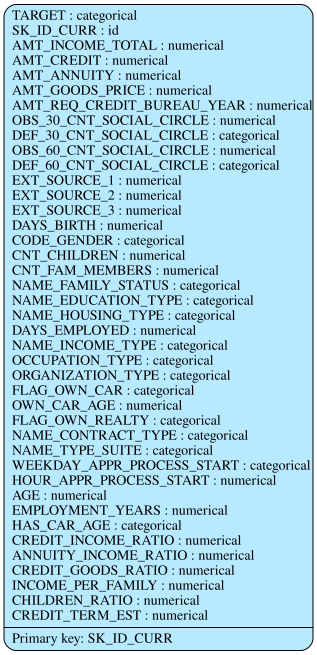

In [ ]:
#Leer metadata usado en sintetizador version 1:
from sdv.metadata import SingleTableMetadata

# 1. Cargar los metadatos desde el archivo JSON
metadata = SingleTableMetadata.load_from_json(filepath='/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/03_Syntetic_Data/metadata_home_credit.json')

# 2. Utilizar la función de visualización
metadata.visualize()

In [ ]:
print(metadata)

{
    "primary_key": "SK_ID_CURR",
    "columns": {
        "TARGET": {
            "sdtype": "categorical"
        },
        "SK_ID_CURR": {
            "sdtype": "id"
        },
        "AMT_INCOME_TOTAL": {
            "sdtype": "numerical"
        },
        "AMT_CREDIT": {
            "sdtype": "numerical"
        },
        "AMT_ANNUITY": {
            "sdtype": "numerical"
        },
        "AMT_GOODS_PRICE": {
            "sdtype": "numerical"
        },
        "AMT_REQ_CREDIT_BUREAU_YEAR": {
            "sdtype": "numerical"
        },
        "OBS_30_CNT_SOCIAL_CIRCLE": {
            "sdtype": "numerical"
        },
        "DEF_30_CNT_SOCIAL_CIRCLE": {
            "sdtype": "categorical"
        },
        "OBS_60_CNT_SOCIAL_CIRCLE": {
            "sdtype": "numerical"
        },
        "DEF_60_CNT_SOCIAL_CIRCLE": {
            "sdtype": "categorical"
        },
        "EXT_SOURCE_1": {
            "sdtype": "numerical"
        },
        "EXT_SOURCE_2": {
            "

In [ ]:
#Sin embargo ahora vamos a crear un nuevo sintetizador ya que nuestras variable estan cambiando respecto al ametadata de la version 1
# =========================================================
# 5.4.4 CONFIGURACIÓN DEL NUEVO SINTETIZADOR
# =========================================================

df_base_v2 = df_real[variables_base_v2].copy()

print("Dimensiones dataset base V2:")
print(df_base_v2.shape)

print("\nPrimeras columnas:")
print(df_base_v2.columns.tolist())

Dimensiones dataset base V2:
(307507, 33)

Primeras columnas:
['TARGET', 'SK_ID_CURR', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'CODE_GENDER', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'NAME_FAMILY_STATUS', 'NAME_EDUCATION_TYPE', 'NAME_HOUSING_TYPE', 'DAYS_EMPLOYED', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'FLAG_OWN_CAR', 'OWN_CAR_AGE', 'FLAG_OWN_REALTY', 'NAME_CONTRACT_TYPE', 'NAME_TYPE_SUITE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'HAS_CAR_AGE']


In [ ]:
#Comprobar tipos de datos - Esto es importante porque vamos a reconstruir el metadata desde cero para V2, en lugar de reutilizar ciegamente el metadata de V1.
print(df_base_v2.dtypes)

TARGET                          int64
SK_ID_CURR                      int64
AMT_INCOME_TOTAL              float64
AMT_CREDIT                    float64
AMT_ANNUITY                   float64
AMT_GOODS_PRICE               float64
AMT_REQ_CREDIT_BUREAU_YEAR    float64
OBS_30_CNT_SOCIAL_CIRCLE      float64
DEF_30_CNT_SOCIAL_CIRCLE      float64
OBS_60_CNT_SOCIAL_CIRCLE      float64
DEF_60_CNT_SOCIAL_CIRCLE      float64
EXT_SOURCE_1                  float64
EXT_SOURCE_2                  float64
EXT_SOURCE_3                  float64
DAYS_BIRTH                      int64
CODE_GENDER                    object
CNT_CHILDREN                    int64
CNT_FAM_MEMBERS               float64
NAME_FAMILY_STATUS             object
NAME_EDUCATION_TYPE            object
NAME_HOUSING_TYPE              object
DAYS_EMPLOYED                 float64
NAME_INCOME_TYPE               object
OCCUPATION_TYPE                object
ORGANIZATION_TYPE              object
FLAG_OWN_CAR                   object
OWN_CAR_AGE 

In [ ]:
#Crear metadata
from sdv.metadata import SingleTableMetadata

metadata_v2 = SingleTableMetadata()

metadata_v2.detect_from_dataframe(df_base_v2)

print(metadata_v2.to_dict())

{'primary_key': 'SK_ID_CURR', 'columns': {'TARGET': {'sdtype': 'categorical'}, 'SK_ID_CURR': {'sdtype': 'id'}, 'AMT_INCOME_TOTAL': {'sdtype': 'numerical'}, 'AMT_CREDIT': {'sdtype': 'numerical'}, 'AMT_ANNUITY': {'sdtype': 'numerical'}, 'AMT_GOODS_PRICE': {'sdtype': 'numerical'}, 'AMT_REQ_CREDIT_BUREAU_YEAR': {'sdtype': 'numerical'}, 'OBS_30_CNT_SOCIAL_CIRCLE': {'sdtype': 'numerical'}, 'DEF_30_CNT_SOCIAL_CIRCLE': {'sdtype': 'categorical'}, 'OBS_60_CNT_SOCIAL_CIRCLE': {'sdtype': 'numerical'}, 'DEF_60_CNT_SOCIAL_CIRCLE': {'sdtype': 'categorical'}, 'EXT_SOURCE_1': {'sdtype': 'numerical'}, 'EXT_SOURCE_2': {'sdtype': 'numerical'}, 'EXT_SOURCE_3': {'sdtype': 'numerical'}, 'DAYS_BIRTH': {'sdtype': 'numerical'}, 'CODE_GENDER': {'sdtype': 'categorical'}, 'CNT_CHILDREN': {'sdtype': 'numerical'}, 'CNT_FAM_MEMBERS': {'sdtype': 'numerical'}, 'NAME_FAMILY_STATUS': {'sdtype': 'categorical'}, 'NAME_EDUCATION_TYPE': {'sdtype': 'categorical'}, 'NAME_HOUSING_TYPE': {'sdtype': 'categorical'}, 'DAYS_EMPLOYED

In [ ]:
#Importante
#Como SK_ID_CURR es un identificador, debemos asegurarnos de que siga siendo id.
metadata_v2.update_column(
    column_name="SK_ID_CURR",
    sdtype="id"
)

In [ ]:
#Target debe continuar de forma categoria
metadata_v2.update_column(
    column_name="TARGET",
    sdtype="categorical"
)

In [ ]:
#Validar metadata
metadata_v2.validate()

print("✓ Metadata V2 validado correctamente")

✓ Metadata V2 validado correctamente


##### 5.4.4.1 Configuración del Gaussian Copula

Ahora crearemos el sintetizador.

Pero aquí quiero hacer una distinción importante respecto a V1.

No vamos a cambiar todavía todas las distribuciones manualmente.

Primero queremos medir el efecto de una sola modificación metodológica:

excluir las variables derivadas del proceso generativo y reconstruirlas posteriormente.

Esto nos permite atribuir cualquier cambio principalmente a esa modificación.

Por tanto, mantendremos inicialmente la configuración de Gaussian Copula comparable con V1.

In [ ]:
from sdv.single_table import GaussianCopulaSynthesizer

synthesizer_v2 = GaussianCopulaSynthesizer(
    metadata_v2,
    enforce_min_max_values=True,
    enforce_rounding=True
)

In [ ]:
#Entrenamiento del sintetizador V2
synthesizer_v2.fit(df_base_v2)

#### 5.4.5 Generación del dataset sintético V2.

##### 5.4.5.1 Generar la base sintética

In [ ]:
# =========================================================
# 5.4.5 GENERACIÓN DEL DATASET SINTÉTICO V2
# =========================================================

N_REGISTROS = len(df_real)

df_synth_base_v2 = synthesizer_v2.sample(
    num_rows=N_REGISTROS
)

print("Dimensiones dataset sintético base V2:")
print(df_synth_base_v2.shape)

Dimensiones dataset sintético base V2:
(307507, 33)


In [ ]:
#Comprobacion inicial
print("Número de registros:", len(df_synth_base_v2))
print("Número de variables:", df_synth_base_v2.shape[1])

print("\nPrimeras filas:")
display(df_synth_base_v2.head())

Número de registros: 307507
Número de variables: 33

Primeras filas:


,TARGET,SK_ID_CURR,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,AMT_REQ_CREDIT_BUREAU_YEAR,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH,CODE_GENDER,CNT_CHILDREN,CNT_FAM_MEMBERS,NAME_FAMILY_STATUS,NAME_EDUCATION_TYPE,NAME_HOUSING_TYPE,DAYS_EMPLOYED,NAME_INCOME_TYPE,OCCUPATION_TYPE,ORGANIZATION_TYPE,FLAG_OWN_CAR,OWN_CAR_AGE,FLAG_OWN_REALTY,NAME_CONTRACT_TYPE,NAME_TYPE_SUITE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,HAS_CAR_AGE
0,0,13460034,277653.711,693286.4,46435.6,697626.3,2.0,0.0,0.0,0.0,0.0,0.509252,0.835357,0.694040,-16337,F,0,1.0,Married,Secondary / secondary special,House / apartment,-2841.0,Working,Laborers,Construction,N,8.0,Y,Cash loans,Family,MONDAY,12,0
1,0,2493192,261881.156,759190.3,22927.2,696884.3,1.0,0.0,0.0,0.0,0.0,0.260165,0.674529,0.377846,-15058,M,0,2.0,Married,Secondary / secondary special,House / apartment,-1927.0,Working,Core staff,Business Entity Type 3,Y,9.0,N,Cash loans,Unaccompanied,FRIDAY,15,1
2,0,8589238,110861.275,213489.6,15392.0,172860.4,1.0,3.0,0.0,3.0,0.0,0.345383,0.414573,0.609006,-12657,M,0,1.0,Civil marriage,Higher education,House / apartment,-127.0,Working,Managers,XNA,N,14.0,Y,Revolving loans,Unaccompanied,WEDNESDAY,8,0
3,0,10313411,170670.994,794219.1,10630.6,703535.1,1.0,5.0,0.0,4.0,0.0,0.405693,0.783618,0.350691,-17791,F,0,1.0,Married,Higher education,With parents,-130.0,State servant,Accountants,Kindergarten,N,13.0,Y,Revolving loans,"Spouse, partner",MONDAY,9,1
4,0,2525172,344538.460,613306.0,40910.0,690615.1,0.0,0.0,0.0,0.0,0.0,0.640204,0.587067,0.827915,-23631,F,0,1.0,Married,Secondary / secondary special,House / apartment,-1036.0,Commercial associate,Laborers,Industry: type 3,N,3.0,Y,Cash loans,Unaccompanied,WEDNESDAY,14,0


In [ ]:
print("\nDistribución TARGET - REAL")
print(df_real["TARGET"].value_counts(normalize=True))

print("\nDistribución TARGET - SINTÉTICO V2 BASE")
print(df_synth_base_v2["TARGET"].value_counts(normalize=True))


Distribución TARGET - REAL
TARGET
0    0.91927
1    0.08073
Name: proportion, dtype: float64

Distribución TARGET - SINTÉTICO V2 BASE
TARGET
0    0.919908
1    0.080092
Name: proportion, dtype: float64


In [ ]:
#Comprobacion
print("Columnas generadas:")
print(df_synth_base_v2.columns.tolist())

print("\nNúmero de columnas:")
print(len(df_synth_base_v2.columns))

Columnas generadas:
['TARGET', 'SK_ID_CURR', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'CODE_GENDER', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'NAME_FAMILY_STATUS', 'NAME_EDUCATION_TYPE', 'NAME_HOUSING_TYPE', 'DAYS_EMPLOYED', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'FLAG_OWN_CAR', 'OWN_CAR_AGE', 'FLAG_OWN_REALTY', 'NAME_CONTRACT_TYPE', 'NAME_TYPE_SUITE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'HAS_CAR_AGE']

Número de columnas:
33


In [ ]:
columnas_extra = [
    col for col in df_synth_base_v2.columns
    if col not in variables_base_v2
]

print("Columnas extra:")
print(columnas_extra)

Columnas extra:
[]


In [ ]:
#Genracion de variables derivadas
# =========================================================
# 5.4.5.1 RECONSTRUCCIÓN DE VARIABLES DERIVADAS
# =========================================================

df_synth_v2 = df_synth_base_v2.copy()

# =========================================================
# EDAD DEL CLIENTE
# =========================================================

df_synth_v2["AGE"] = (
    -df_synth_v2["DAYS_BIRTH"] / 365.25
).round(1)


# =========================================================
# ANTIGÜEDAD LABORAL
# =========================================================

df_synth_v2["EMPLOYMENT_YEARS"] = (
    -df_synth_v2["DAYS_EMPLOYED"] / 365.25
).round(1)


# =========================================================
# RELACIÓN CRÉDITO / INGRESO
# =========================================================

df_synth_v2["CREDIT_INCOME_RATIO"] = (
    df_synth_v2["AMT_CREDIT"] /
    df_synth_v2["AMT_INCOME_TOTAL"]
)


# =========================================================
# CUOTA / INGRESO
# =========================================================

df_synth_v2["ANNUITY_INCOME_RATIO"] = (
    df_synth_v2["AMT_ANNUITY"] /
    df_synth_v2["AMT_INCOME_TOTAL"]
)


# =========================================================
# CRÉDITO / VALOR DEL BIEN
# =========================================================

df_synth_v2["CREDIT_GOODS_RATIO"] = (
    df_synth_v2["AMT_CREDIT"] /
    df_synth_v2["AMT_GOODS_PRICE"]
)


# =========================================================
# INGRESO POR MIEMBRO DEL HOGAR
# =========================================================

df_synth_v2["INCOME_PER_FAMILY"] = (
    df_synth_v2["AMT_INCOME_TOTAL"] /
    df_synth_v2["CNT_FAM_MEMBERS"]
)


# =========================================================
# HIJOS POR MIEMBRO DEL HOGAR
# =========================================================

df_synth_v2["CHILDREN_RATIO"] = (
    df_synth_v2["CNT_CHILDREN"] /
    df_synth_v2["CNT_FAM_MEMBERS"]
)


# =========================================================
# PLAZO ESTIMADO DEL CRÉDITO
# =========================================================

df_synth_v2["CREDIT_TERM_EST"] = (
    df_synth_v2["AMT_CREDIT"] /
    df_synth_v2["AMT_ANNUITY"]
)


print("✓ Variables derivadas reconstruidas")
print("Dimensiones:", df_synth_v2.shape)

✓ Variables derivadas reconstruidas
Dimensiones: (307507, 41)


##### 5.4.5.2 Comprobación de las variables

In [ ]:
variables_derivadas_v2 = [
    "AGE",
    "EMPLOYMENT_YEARS",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_GOODS_RATIO",
    "INCOME_PER_FAMILY",
    "CHILDREN_RATIO",
    "CREDIT_TERM_EST"
]

print("Variables derivadas:")
print(variables_derivadas_v2)

print("\n¿Todas están presentes?:")
print(
    all(
        col in df_synth_v2.columns
        for col in variables_derivadas_v2
    )
)

Variables derivadas:
['AGE', 'EMPLOYMENT_YEARS', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 'INCOME_PER_FAMILY', 'CHILDREN_RATIO', 'CREDIT_TERM_EST']

¿Todas están presentes?:
True


In [ ]:
# Verificación de relaciones determinísticas

error_age = (
    df_synth_v2["AGE"] -
    (-df_synth_v2["DAYS_BIRTH"] / 365.25).round(1)
).abs().max()

error_credit_income = (
    df_synth_v2["CREDIT_INCOME_RATIO"] -
    (
        df_synth_v2["AMT_CREDIT"] /
        df_synth_v2["AMT_INCOME_TOTAL"]
    )
).abs().max()

error_children_ratio = (
    df_synth_v2["CHILDREN_RATIO"] -
    (
        df_synth_v2["CNT_CHILDREN"] /
        df_synth_v2["CNT_FAM_MEMBERS"]
    )
).abs().max()

error_credit_term = (
    df_synth_v2["CREDIT_TERM_EST"] -
    (
        df_synth_v2["AMT_CREDIT"] /
        df_synth_v2["AMT_ANNUITY"]
    )
).abs().max()

print("Error AGE:", error_age)
print("Error CREDIT_INCOME_RATIO:", error_credit_income)
print("Error CHILDREN_RATIO:", error_children_ratio)
print("Error CREDIT_TERM_EST:", error_credit_term)

Error AGE: 0.0
Error CREDIT_INCOME_RATIO: 0.0
Error CHILDREN_RATIO: 0.0
Error CREDIT_TERM_EST: 0.0


### 5.5 Validación del dataset sintético V2

#### 5.5.1 Comprobación estructural

In [ ]:
# =========================================================
# 5.5.1 COMPROBACIÓN ESTRUCTURAL
# =========================================================

print("Dimensiones REAL:")
print(df_real.shape)

print("\nDimensiones SINTÉTICO V2:")
print(df_synth_v2.shape)

print("\n¿Mismas columnas?:")
print(
    set(df_real.columns) == set(df_synth_v2.columns)
)

print("\n¿Mismo número de columnas?:")
print(
    len(df_real.columns) == len(df_synth_v2.columns)
)

Dimensiones REAL:
(307507, 41)

Dimensiones SINTÉTICO V2:
(307507, 41)

¿Mismas columnas?:
True

¿Mismo número de columnas?:
True


#### 5.5.2 Comprobar valores nulos

In [ ]:
print("NaN REAL:")
print(df_real.isna().sum().sum())

print("\nNaN SINTÉTICO V2:")
print(df_synth_v2.isna().sum().sum())

NaN REAL:
0

NaN SINTÉTICO V2:
0


#### 5.5.3 Distribución de TARGET

In [ ]:
print("TARGET - REAL")
print(
    df_real["TARGET"]
    .value_counts(normalize=True)
)

print("\nTARGET - SINTÉTICO V2")
print(
    df_synth_v2["TARGET"]
    .value_counts(normalize=True)
)

TARGET - REAL
TARGET
0    0.91927
1    0.08073
Name: proportion, dtype: float64

TARGET - SINTÉTICO V2
TARGET
0    0.919908
1    0.080092
Name: proportion, dtype: float64


#### 5.5.4 Validación de las variables reconstruidas

In [ ]:
variables_derivadas = [
    "AGE",
    "EMPLOYMENT_YEARS",
    "CREDIT_INCOME_RATIO",
    "ANNUITY_INCOME_RATIO",
    "CREDIT_GOODS_RATIO",
    "INCOME_PER_FAMILY",
    "CHILDREN_RATIO",
    "CREDIT_TERM_EST"
]

comparacion_v2 = pd.DataFrame({
    "Real_mean": df_real[variables_derivadas].mean(),
    "V1_mean": df_synth_v1[variables_derivadas].mean(),
    "V2_mean": df_synth_v2[variables_derivadas].mean(),

    "Real_std": df_real[variables_derivadas].std(),
    "V1_std": df_synth_v1[variables_derivadas].std(),
    "V2_std": df_synth_v2[variables_derivadas].std()
})

comparacion_v2

,Real_mean,V1_mean,V2_mean,Real_std,V1_std,V2_std
AGE,43.907056,44.024326,43.997968,11.947970,11.776295,11.787190
EMPLOYMENT_YEARS,6.162292,6.155369,6.100746,5.849177,5.282107,5.006561
CREDIT_INCOME_RATIO,3.957593,3.961784,3.978560,2.689737,2.511683,2.809609
ANNUITY_INCOME_RATIO,0.180930,0.181216,0.182145,0.094573,0.090607,0.102768
CREDIT_GOODS_RATIO,1.122541,1.122722,1.123432,0.125534,0.124023,0.124874
INCOME_PER_FAMILY,93106.532758,93196.870853,137925.445945,101373.872923,59230.895002,85755.620995
CHILDREN_RATIO,0.125501,0.423600,0.002390,0.199577,0.077845,0.038740
CREDIT_TERM_EST,21.612387,21.767343,21.782687,7.824213,9.916737,8.590536


#### 5.5.5 Comprobar específicamente CHILDREN_RATIO

In [ ]:
print("CHILDREN_RATIO")

print("\nREAL")
print(df_real["CHILDREN_RATIO"].describe())

print("\nV1")
print(df_synth_v1["CHILDREN_RATIO"].describe())

print("\nV2")
print(df_synth_v2["CHILDREN_RATIO"].describe())

CHILDREN_RATIO

REAL
count    307507.000000
mean          0.125501
std           0.199577
min           0.000000
25%           0.000000
50%           0.000000
75%           0.333333
max           0.950000
Name: CHILDREN_RATIO, dtype: float64

V1
count    307507.000000
mean          0.423600
std           0.077845
min           0.216078
25%           0.366909
50%           0.418037
75%           0.474653
max           0.775154
Name: CHILDREN_RATIO, dtype: float64

V2
count    307507.00000
mean          0.00239
std           0.03874
min           0.00000
25%           0.00000
50%           0.00000
75%           0.00000
max           1.00000
Name: CHILDREN_RATIO, dtype: float64


In [ ]:
# =========================================================
# DIAGNÓSTICO DE VARIABLES BASE DE CHILDREN_RATIO
# =========================================================

variables_children = [
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS"
]

for col in variables_children:

    print("=" * 60)
    print(col)

    print("\nREAL:")
    print(df_real[col].describe())

    print("\nSINTÉTICO V2:")
    print(df_synth_v2[col].describe())

CNT_CHILDREN

REAL:
count    307507.000000
mean          0.417047
std           0.722119
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          19.000000
Name: CNT_CHILDREN, dtype: float64

SINTÉTICO V2:
count    307507.000000
mean          0.005080
std           0.071318
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           2.000000
Name: CNT_CHILDREN, dtype: float64
CNT_FAM_MEMBERS

REAL:
count    307507.000000
mean          2.152657
std           0.910677
min           1.000000
25%           2.000000
50%           2.000000
75%           3.000000
max          20.000000
Name: CNT_FAM_MEMBERS, dtype: float64

SINTÉTICO V2:
count    307507.000000
mean          1.466477
std           0.837272
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          14.000000
Name: CNT_FAM_MEMBERS, dtype: float64


In [ ]:
# Distribución de CNT_CHILDREN

print("REAL - CNT_CHILDREN")
print(
    df_real["CNT_CHILDREN"]
    .value_counts(normalize=True)
    .sort_index()
)

print("\nV2 - CNT_CHILDREN")
print(
    df_synth_v2["CNT_CHILDREN"]
    .value_counts(normalize=True)
    .sort_index()
)

REAL - CNT_CHILDREN
CNT_CHILDREN
0     0.700371
1     0.198753
2     0.086983
3     0.012088
4     0.001395
5     0.000273
6     0.000068
7     0.000023
8     0.000007
9     0.000007
10    0.000007
11    0.000003
12    0.000007
14    0.000010
19    0.000007
Name: proportion, dtype: float64

V2 - CNT_CHILDREN
CNT_CHILDREN
0    0.994937
1    0.005047
2    0.000016
Name: proportion, dtype: float64


In [ ]:
# Distribución de CNT_FAM_MEMBERS

print("REAL - CNT_FAM_MEMBERS")
print(
    df_real["CNT_FAM_MEMBERS"]
    .value_counts(normalize=True)
    .sort_index()
)

print("\nV2 - CNT_FAM_MEMBERS")
print(
    df_synth_v2["CNT_FAM_MEMBERS"]
    .value_counts(normalize=True)
    .sort_index()
)

REAL - CNT_FAM_MEMBERS
CNT_FAM_MEMBERS
1.0     0.220636
2.0     0.514970
3.0     0.171053
4.0     0.080310
5.0     0.011310
6.0     0.001327
7.0     0.000263
8.0     0.000065
9.0     0.000020
10.0    0.000010
11.0    0.000003
12.0    0.000007
13.0    0.000003
14.0    0.000007
15.0    0.000003
16.0    0.000007
20.0    0.000007
Name: proportion, dtype: float64

V2 - CNT_FAM_MEMBERS
CNT_FAM_MEMBERS
1.0     0.679019
2.0     0.226398
3.0     0.062259
4.0     0.020692
5.0     0.007288
6.0     0.002722
7.0     0.000995
8.0     0.000374
9.0     0.000179
10.0    0.000052
11.0    0.000020
14.0    0.000003
Name: proportion, dtype: float64


In [ ]:
print("Correlación REAL:")
print(
    df_real[
        ["CNT_CHILDREN", "CNT_FAM_MEMBERS"]
    ].corr()
)

print("\nCorrelación V2:")
print(
    df_synth_v2[
        ["CNT_CHILDREN", "CNT_FAM_MEMBERS"]
    ].corr()
)

Correlación REAL:
                 CNT_CHILDREN  CNT_FAM_MEMBERS
CNT_CHILDREN         1.000000         0.879159
CNT_FAM_MEMBERS      0.879159         1.000000

Correlación V2:
                 CNT_CHILDREN  CNT_FAM_MEMBERS
CNT_CHILDREN         1.000000         0.121738
CNT_FAM_MEMBERS      0.121738         1.000000


In [ ]:
# =========================================================
# DIAGNÓSTICO DE CORRELACIONES - VARIABLES NUMÉRICAS
# =========================================================

numeric_cols_diag = [
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "AMT_REQ_CREDIT_BUREAU_YEAR",
    "OBS_30_CNT_SOCIAL_CIRCLE",
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "OBS_60_CNT_SOCIAL_CIRCLE",
    "DEF_60_CNT_SOCIAL_CIRCLE",
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "DAYS_BIRTH",
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "DAYS_EMPLOYED",
    "OWN_CAR_AGE",
    "HOUR_APPR_PROCESS_START"
]

corr_real_diag = df_real[numeric_cols_diag].corr()
corr_v2_diag = df_synth_v2[numeric_cols_diag].corr()

corr_diff_diag = (
    corr_real_diag - corr_v2_diag
).abs()

# Eliminar diagonal
for col in corr_diff_diag.columns:
    corr_diff_diag.loc[col, col] = 0

corr_long = (
    corr_diff_diag
    .stack()
    .reset_index()
)

corr_long.columns = [
    "Variable_1",
    "Variable_2",
    "Diferencia_Absoluta"
]

corr_long = (
    corr_long
    .sort_values(
        "Diferencia_Absoluta",
        ascending=False
    )
)

corr_long.head(20)

,Variable_1,Variable_2,Diferencia_Absoluta
116,DEF_30_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,0.796459
150,DEF_60_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,0.796459
265,CNT_FAM_MEMBERS,CNT_CHILDREN,0.757420
248,CNT_CHILDREN,CNT_FAM_MEMBERS,0.757420
115,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,0.306386
132,OBS_60_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,0.306386
96,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,0.304709
113,DEF_30_CNT_SOCIAL_CIRCLE,OBS_30_CNT_SOCIAL_CIRCLE,0.304709
2,AMT_INCOME_TOTAL,AMT_ANNUITY,0.279559
36,AMT_ANNUITY,AMT_INCOME_TOTAL,0.279559


In [ ]:
#Comprobacion especifica de la TARGET
target_corr_real = (
    df_real[numeric_cols_diag + ["TARGET"]]
    .corr()["TARGET"]
    .drop("TARGET")
)

target_corr_v2 = (
    df_synth_v2[numeric_cols_diag + ["TARGET"]]
    .corr()["TARGET"]
    .drop("TARGET")
)

target_comparison = pd.DataFrame({
    "Corr_Real": target_corr_real,
    "Corr_V2": target_corr_v2
})

target_comparison["Diferencia_Absoluta"] = (
    target_comparison["Corr_Real"] -
    target_comparison["Corr_V2"]
).abs()

target_comparison = target_comparison.sort_values(
    "Diferencia_Absoluta",
    ascending=False
)

target_comparison

,Corr_Real,Corr_V2,Diferencia_Absoluta
EXT_SOURCE_2,-0.160294,-0.048517,0.111777
EXT_SOURCE_3,-0.155899,-0.046273,0.109625
EXT_SOURCE_1,-0.098887,-0.029404,0.069483
DAYS_BIRTH,0.078242,0.020563,0.057679
DAYS_EMPLOYED,0.063366,0.021632,0.041734
AMT_GOODS_PRICE,-0.039625,-0.007115,0.032510
DEF_30_CNT_SOCIAL_CIRCLE,0.032408,0.001004,0.031404
DEF_60_CNT_SOCIAL_CIRCLE,0.031419,0.002097,0.029322
AMT_CREDIT,-0.030371,-0.004698,0.025673
CNT_CHILDREN,0.019189,-0.000186,0.019375


### 5.6 Diagnóstico de importancia predictiva del dataset real

#### 5.6.1 Preparación del dataset para diagnóstico / Relación de las variables con TARGET

In [ ]:
df_real = df_real.copy()

print("Dimensiones dataset real:", df_real.shape)
print("\nDistribución TARGET:")
print(df_real["TARGET"].value_counts())

print("\nProporción TARGET:")
print(df_real["TARGET"].value_counts(normalize=True))

Dimensiones dataset real: (307507, 41)

Distribución TARGET:
TARGET
0    282682
1     24825
Name: count, dtype: int64

Proporción TARGET:
TARGET
0    0.91927
1    0.08073
Name: proportion, dtype: float64


In [ ]:
X_real = df_real.drop(columns=["TARGET", "SK_ID_CURR"])
y_real = df_real["TARGET"]

In [ ]:
print("X_real:", X_real.shape)
print("y_real:", y_real.shape)
print("\nVariables predictoras:")
print(X_real.columns.tolist())

X_real: (307507, 39)
y_real: (307507,)

Variables predictoras:
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'AMT_REQ_CREDIT_BUREAU_YEAR', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_BIRTH', 'CODE_GENDER', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'NAME_FAMILY_STATUS', 'NAME_EDUCATION_TYPE', 'NAME_HOUSING_TYPE', 'DAYS_EMPLOYED', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'FLAG_OWN_CAR', 'OWN_CAR_AGE', 'FLAG_OWN_REALTY', 'NAME_CONTRACT_TYPE', 'NAME_TYPE_SUITE', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'AGE', 'EMPLOYMENT_YEARS', 'HAS_CAR_AGE', 'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_GOODS_RATIO', 'INCOME_PER_FAMILY', 'CHILDREN_RATIO', 'CREDIT_TERM_EST']


Aquí queremos detectar qué variables tienen una relación estadística relevante con TARGET. Para las variables numéricas podemos utilizar la correlación de Spearman, que es más apropiada que Pearson cuando existen relaciones no lineales o distribuciones asimétricas.

In [ ]:
# =========================================================
# 5.6.1 Relación de las variables con TARGET - Correlación de Spearman
# =========================================================

import pandas as pd
import numpy as np

# Copia de trabajo
df_predictivo = df_real.copy()

# Variables numéricas
numeric_features = df_predictivo.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Excluir TARGET de las variables predictoras
numeric_features = [
    col for col in numeric_features
    if col != "TARGET"
]

# Correlación de Spearman con TARGET
corr_target = (
    df_predictivo[numeric_features + ["TARGET"]]
    .corr(method="spearman")["TARGET"]
    .drop("TARGET")
    .sort_values(key=abs, ascending=False)
)

# Tabla de resultados
corr_target_df = pd.DataFrame({
    "Variable": corr_target.index,
    "Correlacion_Spearman": corr_target.values,
    "Correlacion_Absoluta": abs(corr_target.values)
})

corr_target_df.head(20)

,Variable,Correlacion_Spearman,Correlacion_Absoluta
0,EXT_SOURCE_2,-0.147133,0.147133
1,EXT_SOURCE_3,-0.141501,0.141501
2,EXT_SOURCE_1,-0.085389,0.085389
3,DAYS_BIRTH,0.078331,0.078331
4,AGE,-0.078325,0.078325
5,DAYS_EMPLOYED,0.075036,0.075036
6,EMPLOYMENT_YEARS,-0.075020,0.075020
7,CREDIT_GOODS_RATIO,0.066684,0.066684
8,DEF_30_CNT_SOCIAL_CIRCLE,0.032369,0.032369
9,AMT_GOODS_PRICE,-0.031490,0.031490


In [ ]:
#Mostrar las variables mas relacionadas
print("Top 20 variables numéricas con mayor relación con TARGET:\n")

display(
    corr_target_df.head(20)
)

Top 20 variables numéricas con mayor relación con TARGET:



,Variable,Correlacion_Spearman,Correlacion_Absoluta
0,EXT_SOURCE_2,-0.147133,0.147133
1,EXT_SOURCE_3,-0.141501,0.141501
2,EXT_SOURCE_1,-0.085389,0.085389
3,DAYS_BIRTH,0.078331,0.078331
4,AGE,-0.078325,0.078325
5,DAYS_EMPLOYED,0.075036,0.075036
6,EMPLOYMENT_YEARS,-0.075020,0.075020
7,CREDIT_GOODS_RATIO,0.066684,0.066684
8,DEF_30_CNT_SOCIAL_CIRCLE,0.032369,0.032369
9,AMT_GOODS_PRICE,-0.031490,0.031490


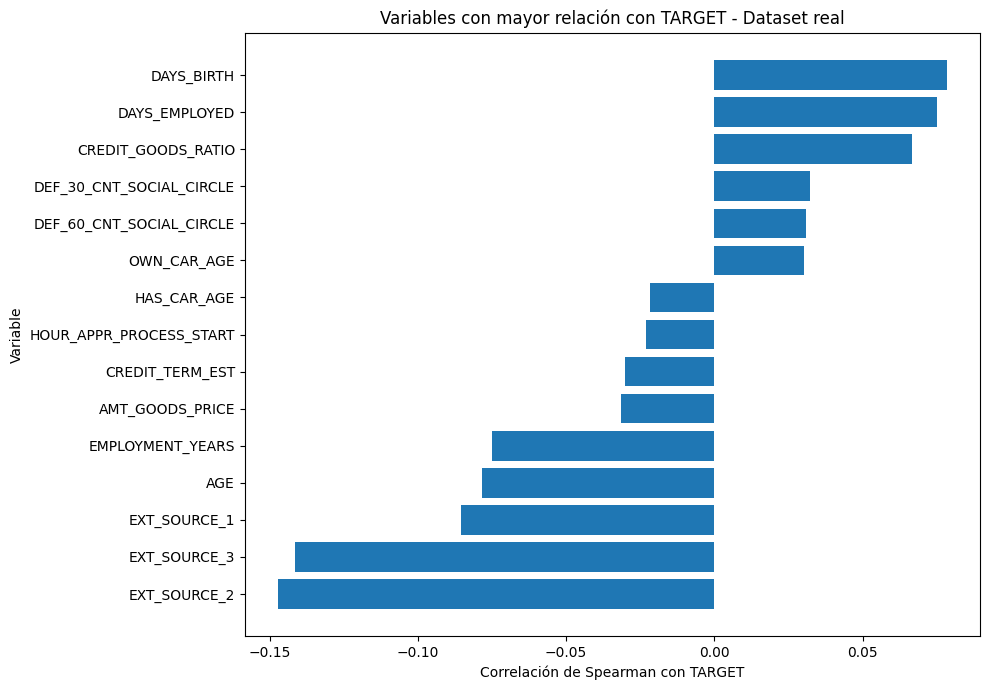

In [ ]:
#Visualizacion
import matplotlib.pyplot as plt

top_corr = corr_target_df.head(15).sort_values(
    "Correlacion_Spearman"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_corr["Variable"],
    top_corr["Correlacion_Spearman"]
)

plt.xlabel("Correlación de Spearman con TARGET")
plt.ylabel("Variable")
plt.title("Variables con mayor relación con TARGET - Dataset real")

plt.tight_layout()
plt.show()

In [ ]:
# =========================================================
# 5.6.1 PREPARACIÓN DE DATOS PARA EL DIAGNÓSTICO
# =========================================================

# Variable objetivo
y_real = df_real["TARGET"].copy()

# Variables predictoras
X_real = df_real.drop(
    columns=["TARGET", "SK_ID_CURR"]
).copy()

print("X_real:", X_real.shape)
print("y_real:", y_real.shape)

print("\nDistribución TARGET:")
print(y_real.value_counts(normalize=True))

X_real: (307507, 39)
y_real: (307507,)

Distribución TARGET:
TARGET
0    0.91927
1    0.08073
Name: proportion, dtype: float64


In [ ]:
#Division train y test
from sklearn.model_selection import train_test_split

X_train_real, X_test_real, y_train_real, y_test_real = train_test_split(
    X_real,
    y_real,
    test_size=0.20,
    stratify=y_real,
    random_state=42
)

print("X_train_real:", X_train_real.shape)
print("X_test_real :", X_test_real.shape)
print("y_train_real:", y_train_real.shape)
print("y_test_real :", y_test_real.shape)

X_train_real: (246005, 39)
X_test_real : (61502, 39)
y_train_real: (246005,)
y_test_real : (61502,)


In [ ]:
#Encoding
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = X_train_real.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X_train_real.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Variables categóricas:", len(categorical_features))
print("Variables numéricas:", len(numeric_features))

Variables categóricas: 12
Variables numéricas: 27


In [ ]:
encoder_diag = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="passthrough"
)

X_train_real_enc = encoder_diag.fit_transform(X_train_real)
X_test_real_enc = encoder_diag.transform(X_test_real)

print("X_train_real_enc:", X_train_real_enc.shape)
print("X_test_real_enc :", X_test_real_enc.shape)

X_train_real_enc: (246005, 150)
X_test_real_enc : (61502, 150)


In [ ]:
feature_names_diag = encoder_diag.get_feature_names_out()

print("Número de variables codificadas:", len(feature_names_diag))
print("Primeras variables:")
print(feature_names_diag[:10])

Número de variables codificadas: 150
Primeras variables:
['categorical__CODE_GENDER_F' 'categorical__CODE_GENDER_M'
 'categorical__NAME_FAMILY_STATUS_Civil marriage'
 'categorical__NAME_FAMILY_STATUS_Married'
 'categorical__NAME_FAMILY_STATUS_Separated'
 'categorical__NAME_FAMILY_STATUS_Single / not married'
 'categorical__NAME_FAMILY_STATUS_Unknown'
 'categorical__NAME_FAMILY_STATUS_Widow'
 'categorical__NAME_EDUCATION_TYPE_Academic degree'
 'categorical__NAME_EDUCATION_TYPE_Higher education']


In [ ]:
#Comprobacion
print(
    "¿Mismo número de variables Train/Test?:",
    X_train_real_enc.shape[1] == X_test_real_enc.shape[1]
)

print(
    "¿NaN Train?:",
    np.isnan(X_train_real_enc).sum()
)

print(
    "¿NaN Test?:",
    np.isnan(X_test_real_enc).sum()
)

¿Mismo número de variables Train/Test?: True
¿NaN Train?: 0
¿NaN Test?: 0


#### 5.6.2 Importancia mediante Mutual Information

La Mutual Information nos permitirá detectar relaciones entre cada variable y TARGET que no necesariamente sean lineales o monotónicas.

In [ ]:
# =========================================================
# 5.6.2 IMPORTANCIA MEDIANTE MUTUAL INFORMATION
# =========================================================

from sklearn.feature_selection import mutual_info_classif

mi_scores = mutual_info_classif(
    X_train_real_enc,
    y_train_real,
    random_state=42
)

mi_df = pd.DataFrame({
    "Variable": feature_names_diag,
    "Mutual_Information": mi_scores
})

mi_df = (
    mi_df
    .sort_values(
        "Mutual_Information",
        ascending=False
    )
    .reset_index(drop=True)
)

mi_df.head(20)

,Variable,Mutual_Information
0,categorical__CODE_GENDER_F,0.046057
1,categorical__NAME_EDUCATION_TYPE_Secondary / s...,0.045293
2,categorical__NAME_FAMILY_STATUS_Married,0.044371
3,categorical__FLAG_OWN_CAR_N,0.043906
4,categorical__FLAG_OWN_REALTY_Y,0.043549
5,categorical__NAME_TYPE_SUITE_Unaccompanied,0.043150
6,categorical__NAME_HOUSING_TYPE_House / apartment,0.040318
7,categorical__NAME_CONTRACT_TYPE_Cash loans,0.037949
8,categorical__NAME_INCOME_TYPE_Working,0.036773
9,categorical__OCCUPATION_TYPE_Laborers,0.033936


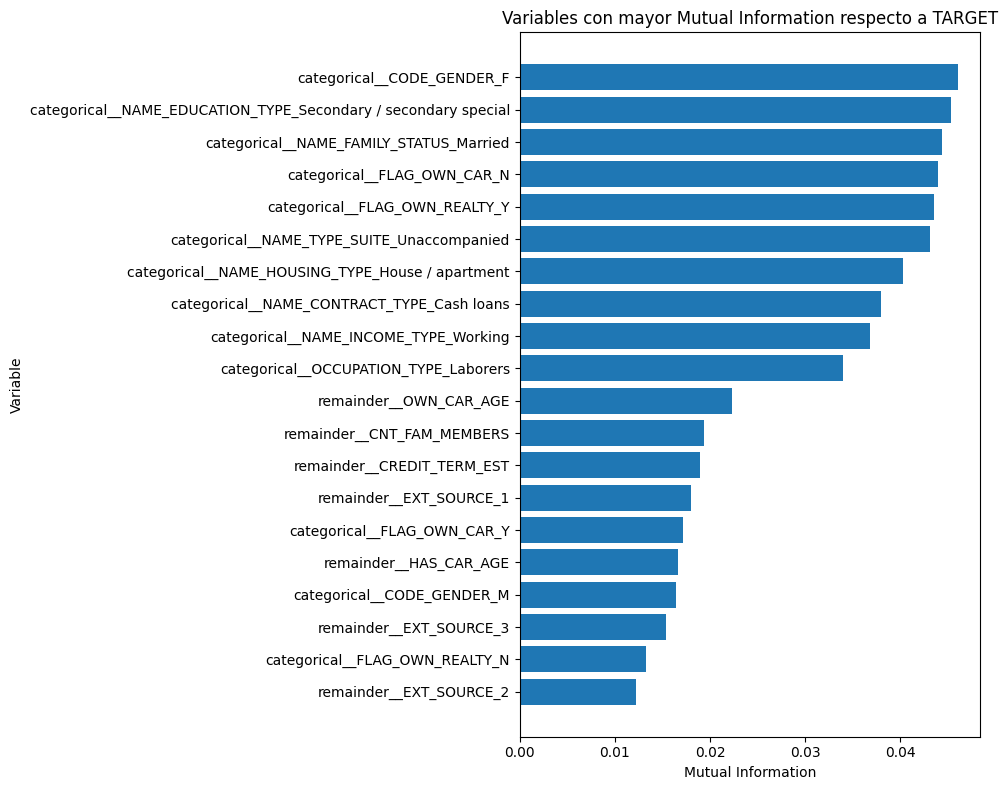

In [ ]:
#Visualizacion
import matplotlib.pyplot as plt

top_mi = mi_df.head(20).sort_values(
    "Mutual_Information"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_mi["Variable"],
    top_mi["Mutual_Information"]
)

plt.xlabel("Mutual Information")
plt.ylabel("Variable")
plt.title(
    "Variables con mayor Mutual Information respecto a TARGET"
)

plt.tight_layout()
plt.show()

                 DATASET REAL
                      │
          ┌───────────┼───────────┐
          ↓           ↓           ↓
      Spearman    Mutual Info   ML
          │           │           │
     asociación    dependencia   importancia
     monotónica    general       predictiva
          │           │           │
          └───────────┼───────────┘
                      ↓
             VARIABLES CRÍTICAS
                      ↓
             GENERACIÓN V2

#### 5.6.3 Importancia mediante modelos de Machine Learning

In [ ]:
# =========================================================
# 5.6.3 IMPORTANCIA MEDIANTE MODELO DE MACHINE LEARNING
# Modelo diagnóstico: LightGBM
# =========================================================

from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

modelo_diag_real = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

modelo_diag_real.fit(
    X_train_real_enc,
    y_train_real
)

# Probabilidades
y_prob_diag_real = modelo_diag_real.predict_proba(
    X_test_real_enc
)[:, 1]

# ROC-AUC
auc_diag_real = roc_auc_score(
    y_test_real,
    y_prob_diag_real
)

print(
    f"ROC-AUC modelo diagnóstico REAL: "
    f"{auc_diag_real:.4f}"
)

ROC-AUC modelo diagnóstico REAL: 0.7656


In [ ]:
# =========================================================
# IMPORTANCIA DE VARIABLES - LIGHTGBM
# =========================================================

import pandas as pd

importance_lgbm_real = pd.DataFrame({
    "Variable": feature_names_diag,
    "Importancia_LightGBM":
        modelo_diag_real.feature_importances_
})

importance_lgbm_real = (
    importance_lgbm_real
    .sort_values(
        "Importancia_LightGBM",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    importance_lgbm_real.head(20)
)

,Variable,Importancia_LightGBM
0,remainder__CREDIT_TERM_EST,769
1,remainder__EXT_SOURCE_3,542
2,remainder__EXT_SOURCE_1,530
3,remainder__EXT_SOURCE_2,425
4,remainder__CREDIT_GOODS_RATIO,276
5,remainder__AMT_ANNUITY,244
6,remainder__DAYS_BIRTH,240
7,remainder__DAYS_EMPLOYED,204
8,remainder__AMT_GOODS_PRICE,193
9,remainder__ANNUITY_INCOME_RATIO,191


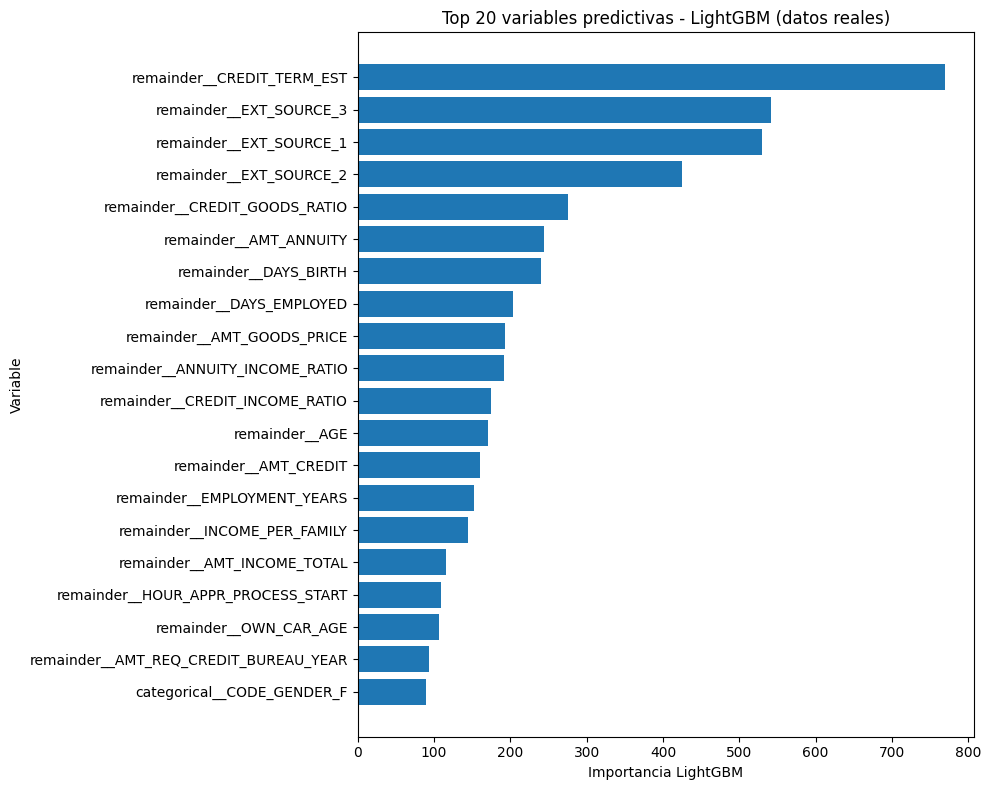

In [ ]:
import matplotlib.pyplot as plt

top_lgbm = (
    importance_lgbm_real
    .head(20)
    .sort_values("Importancia_LightGBM")
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_lgbm["Variable"],
    top_lgbm["Importancia_LightGBM"]
)

plt.xlabel("Importancia LightGBM")
plt.ylabel("Variable")
plt.title(
    "Top 20 variables predictivas - LightGBM (datos reales)"
)

plt.tight_layout()
plt.show()

#### 5.6.4 Identificación de variables críticas

Tenemos tres fuentes de evidencia:

Spearman: asociación monotónica con TARGET.
Mutual Information: dependencia univariada, incluso no lineal.
LightGBM: utilidad de las variables dentro de un modelo multivariable.

Y LightGBM confirma algo especialmente importante:

CREDIT_TERM_EST     → 769
EXT_SOURCE_3        → 542
EXT_SOURCE_1        → 530
EXT_SOURCE_2        → 425
CREDIT_GOODS_RATIO  → 276

Esto fortalece mucho nuestro diagnóstico anterior.

##### 5.6.4.1 Normalizar nombres

Tenemos primero un pequeño problema técnico. Spearman trabaja con nombres como:

EXT_SOURCE_2

mientras que después del ColumnTransformer tenemos:

remainder__EXT_SOURCE_2
categorical__CODE_GENDER_F

Vamos a crear una columna con la variable original.

In [ ]:
# =========================================================
# 5.6.4 IDENTIFICACIÓN DE VARIABLES CRÍTICAS
# 5.6.4.1 Normalización de nombres
# =========================================================

def obtener_variable_original(nombre):

    if nombre.startswith("remainder__"):
        return nombre.replace("remainder__", "")

    if nombre.startswith("categorical__"):
        nombre_limpio = nombre.replace("categorical__", "")

        # Identificar la variable categórica original
        for col in categorical_features:
            if nombre_limpio.startswith(col + "_"):
                return col

    return nombre


mi_df["Variable_Original"] = (
    mi_df["Variable"]
    .apply(obtener_variable_original)
)

importance_lgbm_real["Variable_Original"] = (
    importance_lgbm_real["Variable"]
    .apply(obtener_variable_original)
)

##### 5.6.4.2 Agrupar las variables categóricas

Esto es importante.

Por ejemplo, Mutual Information nos había dado:

CODE_GENDER_F
CODE_GENDER_M

Pero conceptualmente ambas pertenecen a:

CODE_GENDER

Por tanto, agregamos los scores de las dummies.

In [ ]:
#PAra mutual information
mi_agrupado = (
    mi_df
    .groupby("Variable_Original", as_index=False)
    ["Mutual_Information"]
    .sum()
)

In [ ]:
#PAra lightGBM
lgbm_agrupado = (
    importance_lgbm_real
    .groupby("Variable_Original", as_index=False)
    ["Importancia_LightGBM"]
    .sum()
)

Ahora cada variable original tendrá un único valor.

##### 5.6.4.3 Construir tabla conjunta

In [ ]:
#Spearman ya esta anivel de variable original
ranking_global = (
    corr_target_df[
        ["Variable", "Correlacion_Absoluta"]
    ]
    .merge(
        mi_agrupado,
        left_on="Variable",
        right_on="Variable_Original",
        how="outer"
    )
)

ranking_global["Variable"] = (
    ranking_global["Variable"]
    .fillna(ranking_global["Variable_Original"])
)

ranking_global = ranking_global.drop(
    columns=["Variable_Original"]
)

ranking_global = ranking_global.merge(
    lgbm_agrupado,
    left_on="Variable",
    right_on="Variable_Original",
    how="outer"
)

ranking_global["Variable"] = (
    ranking_global["Variable"]
    .fillna(ranking_global["Variable_Original"])
)

ranking_global = ranking_global.drop(
    columns=["Variable_Original"]
)

ranking_global = ranking_global.fillna(0)

##### 5.6.4.4 Crear rankings

Aquí está la parte importante.

No vamos a sumar:

0.147 + 0.046 + 769

porque eso evidentemente haría que LightGBM dominase completamente el resultado.

En su lugar convertiremos cada métrica en un ranking:

In [ ]:
ranking_global["Rank_Spearman"] = (
    ranking_global["Correlacion_Absoluta"]
    .rank(
        ascending=False,
        method="min"
    )
)

ranking_global["Rank_MI"] = (
    ranking_global["Mutual_Information"]
    .rank(
        ascending=False,
        method="min"
    )
)

ranking_global["Rank_LightGBM"] = (
    ranking_global["Importancia_LightGBM"]
    .rank(
        ascending=False,
        method="min"
    )
)

In [ ]:
#Construimos puntaje golbal
ranking_global["Puntaje_Ranking"] = (
    ranking_global["Rank_Spearman"] +
    ranking_global["Rank_MI"] +
    ranking_global["Rank_LightGBM"]
)

En este caso:

menor puntaje = mayor relevancia global.

Finalmente:

In [ ]:
ranking_global = (
    ranking_global
    .sort_values(
        "Puntaje_Ranking",
        ascending=True
    )
    .reset_index(drop=True)
)

display(
    ranking_global[
        [
            "Variable",
            "Correlacion_Absoluta",
            "Mutual_Information",
            "Importancia_LightGBM",
            "Rank_Spearman",
            "Rank_MI",
            "Rank_LightGBM",
            "Puntaje_Ranking"
        ]
    ].head(20)
)

,Variable,Correlacion_Absoluta,Mutual_Information,Importancia_LightGBM,Rank_Spearman,Rank_MI,Rank_LightGBM,Puntaje_Ranking
0,EXT_SOURCE_3,0.141501,0.015412,542.0,2.0,18.0,2.0,22.0
1,EXT_SOURCE_1,0.085389,0.018028,530.0,3.0,16.0,3.0,22.0
2,EXT_SOURCE_2,0.147133,0.012203,425.0,1.0,19.0,4.0,24.0
3,CREDIT_TERM_EST,0.030262,0.018989,769.0,12.0,15.0,1.0,28.0
4,CREDIT_GOODS_RATIO,0.066684,0.009003,276.0,8.0,21.0,5.0,34.0
5,DAYS_EMPLOYED,0.075036,0.006171,204.0,6.0,24.0,9.0,39.0
6,DAYS_BIRTH,0.078331,0.003920,240.0,4.0,29.0,7.0,40.0
7,AMT_GOODS_PRICE,0.031490,0.005099,193.0,10.0,26.0,10.0,46.0
8,OWN_CAR_AGE,0.030069,0.022267,106.0,13.0,12.0,21.0,46.0
9,ORGANIZATION_TYPE,0.000000,0.029699,222.0,29.0,11.0,8.0,48.0


#### 5.6.5 Implicaciones para la generación sintética V2

El análisis conjunto mediante correlación de Spearman, Mutual Information e importancia de variables obtenida mediante LightGBM permitió identificar las variables con mayor relevancia predictiva respecto a TARGET.

Los resultados muestran que EXT_SOURCE_1, EXT_SOURCE_2 y EXT_SOURCE_3 constituyen un núcleo especialmente relevante, al ocupar posiciones destacadas tanto en el análisis de asociación como en la importancia obtenida mediante LightGBM. Asimismo, variables como CREDIT_TERM_EST, CREDIT_GOODS_RATIO, DAYS_BIRTH y DAYS_EMPLOYED presentan una contribución relevante al modelo predictivo.

La comparación con el dataset sintético V2 mostró que Gaussian Copula conserva aproximadamente la distribución de TARGET, pero debilita de forma considerable algunas de las relaciones entre TARGET y las variables predictivamente relevantes, especialmente las correspondientes a EXT_SOURCE_1, EXT_SOURCE_2 y EXT_SOURCE_3.

Adicionalmente, se detectaron pérdidas importantes en determinadas dependencias entre variables, como CNT_CHILDREN–CNT_FAM_MEMBERS y DEF_30_CNT_SOCIAL_CIRCLE–DEF_60_CNT_SOCIAL_CIRCLE. Esto evidencia que la similitud de las distribuciones marginales no garantiza la conservación de la estructura multivariante ni de la utilidad predictiva.

Por otra parte, variables derivadas como CREDIT_TERM_EST, CREDIT_GOODS_RATIO, AGE y EMPLOYMENT_YEARS deben continuar reconstruyéndose determinísticamente a partir de sus variables base, evitando su generación independiente.

En consecuencia, las siguientes iteraciones del proceso de síntesis deberán evaluarse no únicamente mediante fidelidad estadística marginal, sino también considerando la conservación de dependencias estructurales y, especialmente, de las relaciones asociadas con las variables de mayor relevancia predictiva.

### 5.7 Optimización de la generación sintética

#### 5.7.1 Definición de criterios de mejora

Vamos a dejar explícito qué problemas debe solucionar la siguiente iteración.

De nuestros experimentos anteriores tenemos tres criterios.

**Criterio 1 — Preservación de TARGET**

Esto V2 ya lo hace muy bien:

REAL
TARGET=1 → 8.073%

V2
TARGET=1 → 8.009%

Por tanto, V2.1 debe mantener aproximadamente esa proporción.

In [ ]:
# =========================================================
# 5.7.1 CRITERIOS DE MEJORA PARA V2.1
# =========================================================

target_real = df_real["TARGET"].mean()
target_v2 = df_synth_v2["TARGET"].mean()

dif_target = abs(target_real - target_v2)

print(f"TARGET Real : {target_real:.6f}")
print(f"TARGET V2   : {target_v2:.6f}")
print(f"Diferencia  : {dif_target:.6f}")

TARGET Real : 0.080730
TARGET V2   : 0.080092
Diferencia  : 0.000637


**Criterio 2 — Preservación de relaciones predictivas críticas**

Aquí está el problema principal.

Vamos a definir las variables críticas que identificamos en 5.6:

In [ ]:
variables_criticas = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "CREDIT_TERM_EST",
    "CREDIT_GOODS_RATIO",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED"
]

Pero hay un detalle importante.

CREDIT_TERM_EST y CREDIT_GOODS_RATIO son derivadas:

AMT_CREDIT + AMT_ANNUITY
             ↓
      CREDIT_TERM_EST

AMT_CREDIT + AMT_GOODS_PRICE
             ↓
      CREDIT_GOODS_RATIO

Por tanto, no vamos a introducirlas otra vez al sintetizador.

La estrategia seguirá siendo:

Sintetizar variables base
          ↓
Reconstruir variables derivadas
          ↓
Evaluar si recuperan su relación con TARGET

Eso es metodológicamente más limpio.

In [ ]:
#Creamos una tabla baseline de relaciones críticas
# =========================================================
# BASELINE DE RELACIONES TARGET-X
# =========================================================

variables_criticas = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "CREDIT_TERM_EST",
    "CREDIT_GOODS_RATIO",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED"
]

baseline_relaciones = []

for variable in variables_criticas:

    corr_real = df_real[
        [variable, "TARGET"]
    ].corr().iloc[0, 1]

    corr_v2 = df_synth_v2[
        [variable, "TARGET"]
    ].corr().iloc[0, 1]

    baseline_relaciones.append({
        "Variable": variable,
        "Corr_Real": corr_real,
        "Corr_V2": corr_v2,
        "Diferencia_V2": abs(corr_real - corr_v2)
    })

baseline_relaciones = pd.DataFrame(
    baseline_relaciones
).sort_values(
    "Diferencia_V2",
    ascending=False
)

baseline_relaciones

,Variable,Corr_Real,Corr_V2,Diferencia_V2
1,EXT_SOURCE_2,-0.160294,-0.048517,0.111777
2,EXT_SOURCE_3,-0.155899,-0.046273,0.109625
0,EXT_SOURCE_1,-0.098887,-0.029404,0.069483
5,DAYS_BIRTH,0.078242,0.020563,0.057679
4,CREDIT_GOODS_RATIO,0.068482,0.017630,0.050851
6,DAYS_EMPLOYED,0.063366,0.021632,0.041734
3,CREDIT_TERM_EST,-0.032102,-0.007778,0.024323


**Criterio 3 — Preservación de dependencias estructurales**

Aquí tenemos dos relaciones especialmente problemáticas:

CNT_CHILDREN ↔ CNT_FAM_MEMBERS

DEF_30_CNT_SOCIAL_CIRCLE ↔ DEF_60_CNT_SOCIAL_CIRCLE

Vamos a guardar también su baseline:

In [ ]:
# =========================================================
# BASELINE DE DEPENDENCIAS ESTRUCTURALES
# =========================================================

pares_estructurales = [
    (
        "CNT_CHILDREN",
        "CNT_FAM_MEMBERS"
    ),
    (
        "DEF_30_CNT_SOCIAL_CIRCLE",
        "DEF_60_CNT_SOCIAL_CIRCLE"
    )
]

baseline_dependencias = []

for var1, var2 in pares_estructurales:

    corr_real = df_real[
        [var1, var2]
    ].corr().iloc[0, 1]

    corr_v2 = df_synth_v2[
        [var1, var2]
    ].corr().iloc[0, 1]

    baseline_dependencias.append({
        "Relacion": f"{var1} - {var2}",
        "Corr_Real": corr_real,
        "Corr_V2": corr_v2,
        "Diferencia_V2": abs(
            corr_real - corr_v2
        )
    })

baseline_dependencias = pd.DataFrame(
    baseline_dependencias
)

baseline_dependencias

,Relacion,Corr_Real,Corr_V2,Diferencia_V2
0,CNT_CHILDREN - CNT_FAM_MEMBERS,0.879159,0.121738,0.757420
1,DEF_30_CNT_SOCIAL_CIRCLE - DEF_60_CNT_SOCIAL_C...,0.860518,0.064059,0.796459


**¿Cuándo consideraremos que V2.1 mejora?**

Aquí no pondría una regla arbitraria como:

"todas las correlaciones deben diferir menos de 0.02".

Eso sería difícil de justificar.

Utilizaremos un criterio comparativo respecto a V2:

V2.1 será considerada una mejora si reduce sistemáticamente la pérdida de las relaciones predictivas y estructurales identificadas, sin deteriorar sustancialmente la distribución de TARGET ni la fidelidad estadística general.

Esto es mucho más defendible.

Al final tendremos algo como:

| Variable        |   Real |     V2 | V2.1 | ¿Mejora? |
| --------------- | -----: | -----: | ---: | -------- |
| EXT_SOURCE_2    | -0.160 | -0.049 |    ? | ?        |
| EXT_SOURCE_3    | -0.156 | -0.046 |    ? | ?        |
| EXT_SOURCE_1    | -0.099 | -0.029 |    ? | ?        |
| CREDIT_TERM_EST |    ... |    ... |    ? | ?        |

y para dependencias:

| Relación          |  Real |    V2 | V2.1 |
| ----------------- | ----: | ----: | ---: |
| CHILDREN ↔ FAMILY | 0.879 | 0.122 |    ? |
| DEF30 ↔ DEF60     |  Real |    V2 |    ? |

**Criterios de mejora**. La optimización de la segunda generación sintética no se orientará exclusivamente a maximizar la similitud de las distribuciones marginales. A partir del diagnóstico realizado, se establecen como criterios principales la conservación de la distribución de la variable objetivo, la reducción de las diferencias en las relaciones entre TARGET y las variables de mayor relevancia predictiva, y la preservación de dependencias estructurales relevantes entre variables. La versión V2 será utilizada como baseline para determinar si las modificaciones introducidas en V2.1 producen una mejora efectiva.

#### 5.7.2 Tratamiento de variables discretas/de conteo

##### 5.7.2.1 Identificación de variables discretas

In [ ]:
# =========================================================
# 5.7.2 TRATAMIENTO DE VARIABLES DISCRETAS / DE CONTEO
# =========================================================

variables_conteo = [
    "CNT_CHILDREN",
    "CNT_FAM_MEMBERS",
    "DEF_30_CNT_SOCIAL_CIRCLE",
    "DEF_60_CNT_SOCIAL_CIRCLE",
    "OBS_30_CNT_SOCIAL_CIRCLE",
    "OBS_60_CNT_SOCIAL_CIRCLE"
]

for col in variables_conteo:

    print("=" * 60)
    print(col)

    print("Tipo:", df_real[col].dtype)
    print("Valores únicos:", df_real[col].nunique())

    print(
        "Rango:",
        df_real[col].min(),
        "-",
        df_real[col].max()
    )

CNT_CHILDREN
Tipo: int64
Valores únicos: 15
Rango: 0 - 19
CNT_FAM_MEMBERS
Tipo: float64
Valores únicos: 17
Rango: 1.0 - 20.0
DEF_30_CNT_SOCIAL_CIRCLE
Tipo: float64
Valores únicos: 10
Rango: 0.0 - 34.0
DEF_60_CNT_SOCIAL_CIRCLE
Tipo: float64
Valores únicos: 9
Rango: 0.0 - 24.0
OBS_30_CNT_SOCIAL_CIRCLE
Tipo: float64
Valores únicos: 33
Rango: 0.0 - 348.0
OBS_60_CNT_SOCIAL_CIRCLE
Tipo: float64
Valores únicos: 33
Rango: 0.0 - 344.0


##### 5.7.2.2 Revisar cómo las está interpretando el metadata

In [ ]:
# =========================================================
# REVISIÓN DEL METADATA
# =========================================================

for col in variables_conteo:

    print(
        col,
        "→",
        metadata.columns[col]
    )

CNT_CHILDREN → {'sdtype': 'numerical'}
CNT_FAM_MEMBERS → {'sdtype': 'numerical'}
DEF_30_CNT_SOCIAL_CIRCLE → {'sdtype': 'categorical'}
DEF_60_CNT_SOCIAL_CIRCLE → {'sdtype': 'categorical'}
OBS_30_CNT_SOCIAL_CIRCLE → {'sdtype': 'numerical'}
OBS_60_CNT_SOCIAL_CIRCLE → {'sdtype': 'numerical'}


##### 5.7.2.3 Decisión para CNT_CHILDREN y CNT_FAM_MEMBERS

In [ ]:
#Crear metadata V2.1 sin modificar el anterior
# =========================================================
# METADATA PARA V2.1
# =========================================================

from sdv.metadata import SingleTableMetadata

metadata_v21 = SingleTableMetadata.load_from_dict(
    metadata.to_dict()
)

metadata_v21.update_column(
    column_name="CNT_CHILDREN",
    sdtype="categorical"
)

metadata_v21.update_column(
    column_name="CNT_FAM_MEMBERS",
    sdtype="categorical"
)

¿Por qué no modificamos todavía DEF30/DEF60?

Porque según el metadata que me mostraste anteriormente:

DEF_30_CNT_SOCIAL_CIRCLE → categorical
DEF_60_CNT_SOCIAL_CIRCLE → categorical

Ya estaban siendo tratadas como categóricas y aun así su dependencia se perdió.

##### 5.7.2.4 Verificación del nuevo metadata

In [ ]:
# =========================================================
# COMPROBACIÓN METADATA V2.1
# =========================================================

metadata_v21_dict = metadata_v21.to_dict()

for col in variables_conteo:

    print(
        col,
        "→",
        metadata_v21_dict["columns"][col]["sdtype"]
    )

CNT_CHILDREN → categorical
CNT_FAM_MEMBERS → categorical
DEF_30_CNT_SOCIAL_CIRCLE → categorical
DEF_60_CNT_SOCIAL_CIRCLE → categorical
OBS_30_CNT_SOCIAL_CIRCLE → numerical
OBS_60_CNT_SOCIAL_CIRCLE → numerical


##### 5.7.2.5 Algo que NO debemos hacer

No hagamos cosas como:

df_synth_v21["CNT_CHILDREN"] = ...

para forzar manualmente la distribución real.

Tampoco:

df_synth_v21["TARGET"] = ...

para aumentar artificialmente la correlación.

Eso nos daría mejores métricas, pero metodológicamente sería muy cuestionable porque estaríamos construyendo el resultado que queremos demostrar.

La V2.1 tiene que mejorar porque modificamos razonablemente el proceso de síntesis, no porque corregimos manualmente los datos después de generarlos.

#### 5.7.3 Estrategia de preservación de relaciones críticas.

##### 5.7.3.1 Por qué no debemos manipular las EXT_SOURCE

No vamos a hacer algo como:

df_synth["EXT_SOURCE_2"] = función(TARGET)

porque estaríamos introduciendo artificialmente la relación que queremos encontrar.

Tampoco deberíamos modificar posteriormente TARGET.

Queremos que esa dependencia sea aprendida por el sintetizador.

##### 5.7.3.2 Generación condicional respecto a TARGET

Aquí sí podemos hacer un experimento metodológicamente interesante.

Nuestro problema tiene un fuerte desbalance:

TARGET = 0 → ~91.9%
TARGET = 1 → ~8.1%

Gaussian Copula tiene muchos menos registros de la clase positiva de los que aprender:

307,507 × 0.0807 ≈ 24,800 defaults

Aunque 24 mil observaciones no son pocas, la distribución conjunta de las variables dentro de esa clase puede resultar más difícil de representar.

Para V2.1 vamos a conservar explícitamente la distribución de TARGET mediante muestreo condicional.

La idea será:

                  Gaussian Copula entrenada
                           │
                 ┌─────────┴─────────┐
                 ↓                   ↓
          generar TARGET=0     generar TARGET=1
                 │                   │
                 └─────────┬─────────┘
                           ↓
                       combinar
                           ↓
                          V2.1

Esto no significa fabricar relaciones con TARGET. El sintetizador sigue generando las demás variables condicionado a cada clase.

##### 5.7.3.3 Calcular número de registros por clase

In [ ]:
# =========================================================
# 5.7.3 ESTRATEGIA DE PRESERVACIÓN DE TARGET
# =========================================================

n_total = len(df_real)

prop_target = (
    df_real["TARGET"]
    .value_counts(normalize=True)
    .sort_index()
)

n_target_0 = round(
    n_total * prop_target.loc[0]
)

n_target_1 = n_total - n_target_0

print("Total:", n_total)

print("\nTARGET = 0")
print("Proporción:", prop_target.loc[0])
print("Registros :", n_target_0)

print("\nTARGET = 1")
print("Proporción:", prop_target.loc[1])
print("Registros :", n_target_1)

Total: 307507

TARGET = 0
Proporción: 0.9192701304360551
Registros : 282682

TARGET = 1
Proporción: 0.08072986956394489
Registros : 24825


##### 5.7.3.4 Configurar el sintetizador V2.1

In [ ]:
from sdv.single_table import GaussianCopulaSynthesizer

synthesizer_v21 = GaussianCopulaSynthesizer(
    metadata_v21,
    enforce_min_max_values=True,
    enforce_rounding=True
)

In [ ]:
#Entrenamos sobre el mismo dataset base utilizado para V2 --#AQUI HUBO ERROR DE METADATA - LA DATA BASE NO TIENE LAS COLUMNAS DERIBVADAS QUE TIENE LA METADATA
#synthesizer_v21.fit(
#    df_base_v2
#)
#
#print("✓ Gaussian Copula V2.1 entrenada correctamente")

In [ ]:
#CORRIGIENDO ERROR METADATA
# =========================================================
# RECREAR METADATA V2.1 A PARTIR DEL DATASET BASE V2
# =========================================================

from sdv.metadata import SingleTableMetadata

metadata_v21 = SingleTableMetadata()

# Detectar únicamente las 33 variables presentes en df_base_v2
metadata_v21.detect_from_dataframe(df_base_v2)

# Variables que queremos controlar explícitamente
metadata_v21.update_column(
    column_name="TARGET",
    sdtype="categorical"
)

metadata_v21.update_column(
    column_name="SK_ID_CURR",
    sdtype="id"
)

metadata_v21.update_column(
    column_name="CNT_CHILDREN",
    sdtype="categorical"
)

metadata_v21.update_column(
    column_name="CNT_FAM_MEMBERS",
    sdtype="categorical"
)

metadata_v21.update_column(
    column_name="DEF_30_CNT_SOCIAL_CIRCLE",
    sdtype="categorical"
)

metadata_v21.update_column(
    column_name="DEF_60_CNT_SOCIAL_CIRCLE",
    sdtype="categorical"
)

metadata_v21.validate()

print("✓ Metadata V2.1 creado correctamente")

✓ Metadata V2.1 creado correctamente


In [ ]:
#REalizamos la comprobacion antes de volver a entrenar
print("Columnas df_base_v2:", df_base_v2.shape[1])
print(
    "Columnas metadata_v21:",
    len(metadata_v21.to_dict()["columns"])
)

print(
    "\n¿Coinciden?:",
    df_base_v2.shape[1] ==
    len(metadata_v21.to_dict()["columns"])
)

Columnas df_base_v2: 33
Columnas metadata_v21: 33

¿Coinciden?: True


In [ ]:
#Confirmarmos que la derivadas desaparecieron
derivadas_en_metadata = [
    col for col in variables_derivadas_v2
    if col in metadata_v21.to_dict()["columns"]
]

print("Variables derivadas todavía en metadata:")
print(derivadas_en_metadata)

Variables derivadas todavía en metadata:
[]


In [ ]:
#Entrenamos V2.1
from sdv.single_table import GaussianCopulaSynthesizer

synthesizer_v21 = GaussianCopulaSynthesizer(
    metadata_v21,
    enforce_min_max_values=True,
    enforce_rounding=True
)

synthesizer_v21.fit(df_base_v2)

print("✓ Gaussian Copula V2.1 entrenada correctamente")

✓ Gaussian Copula V2.1 entrenada correctamente


#### 5.7.4 Generación del dataset sintético V2.1  

La idea en V2.1 es:

  * usar el synthesizer_v21 entrenado sobre las 33 variables base;
  * generar por separado TARGET=0 y TARGET=1;
  * respetar la misma proporción del dataset real;
  * unir ambos subconjuntos;
  * reconstruir después las 8 variables derivadas.

##### 5.7.4.1 Generación condicional por TARGET

In [ ]:
# =========================================================
# 5.7.4 GENERACIÓN DEL DATASET SINTÉTICO V2.1
# =========================================================

from sdv.sampling import Condition

cond_target_0 = Condition(
    num_rows=n_target_0,
    column_values={
        "TARGET": 0
    }
)

cond_target_1 = Condition(
    num_rows=n_target_1,
    column_values={
        "TARGET": 1
    }
)

In [ ]:
#Se genera ambos grupos
df_v21_target_0 = synthesizer_v21.sample_from_conditions(
    conditions=[cond_target_0]
)

df_v21_target_1 = synthesizer_v21.sample_from_conditions(
    conditions=[cond_target_1]
)

print("TARGET=0:", df_v21_target_0.shape)
print("TARGET=1:", df_v21_target_1.shape)

Sampling conditions: 100%|██████████| 24825/24825 [00:02<00:00, 9232.71it/s]

TARGET=0: (282682, 33)
TARGET=1: (24825, 33)


##### 5.7.4.2 Unir ambos subconjuntos

In [ ]:
import pandas as pd

df_synth_base_v21 = pd.concat(
    [
        df_v21_target_0,
        df_v21_target_1
    ],
    ignore_index=True
)

print("Dimensiones V2.1 base:")
print(df_synth_base_v21.shape)

print("\nDistribución TARGET:")
print(df_synth_base_v21["TARGET"].value_counts())

print("\nProporción TARGET:")
print(
    df_synth_base_v21["TARGET"]
    .value_counts(normalize=True)
)

Dimensiones V2.1 base:
(307507, 33)

Distribución TARGET:
TARGET
0    282682
1     24825
Name: count, dtype: int64

Proporción TARGET:
TARGET
0    0.91927
1    0.08073
Name: proportion, dtype: float64


##### 5.7.4.3 Mezclar los registros

In [ ]:
df_synth_base_v21 = (
    df_synth_base_v21
    .sample(
        frac=1,
        random_state=42
    )
    .reset_index(drop=True)
)

df_synth_base_v21.head()

,TARGET,SK_ID_CURR,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,AMT_REQ_CREDIT_BUREAU_YEAR,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,DAYS_BIRTH,CODE_GENDER,CNT_CHILDREN,CNT_FAM_MEMBERS,NAME_FAMILY_STATUS,NAME_EDUCATION_TYPE,NAME_HOUSING_TYPE,DAYS_EMPLOYED,NAME_INCOME_TYPE,OCCUPATION_TYPE,ORGANIZATION_TYPE,FLAG_OWN_CAR,OWN_CAR_AGE,FLAG_OWN_REALTY,NAME_CONTRACT_TYPE,NAME_TYPE_SUITE,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,HAS_CAR_AGE
0,0,13713112,43584.265,229606.9,9767.7,160785.5,0.0,4.0,0.0,4.0,0.0,0.539578,0.268957,0.565568,-15041,M,0,3.0,Married,Secondary / secondary special,House / apartment,-1534.0,Commercial associate,Cooking staff,Business Entity Type 1,N,7.0,N,Cash loans,Unaccompanied,FRIDAY,17,0
1,0,9711802,50329.953,1128510.7,39305.7,1099591.9,0.0,0.0,0.0,0.0,0.0,0.390012,0.096417,0.356636,-22757,F,0,2.0,Married,Secondary / secondary special,House / apartment,-8791.0,Working,Laborers,Industry: type 3,N,6.0,Y,Cash loans,Unaccompanied,WEDNESDAY,16,0
2,0,6807857,97045.804,305144.0,14631.9,265165.8,0.0,0.0,0.0,0.0,0.0,0.228948,0.547175,0.293784,-15274,M,2,2.0,Married,Secondary / secondary special,House / apartment,-162.0,Commercial associate,Laborers,XNA,N,8.0,Y,Cash loans,Unaccompanied,MONDAY,15,0
3,0,9587602,105618.243,269905.6,16325.5,233552.7,1.0,3.0,0.0,3.0,0.0,0.401440,0.737247,0.603761,-13221,M,2,2.0,Married,Secondary / secondary special,With parents,-1161.0,Working,High skill tech staff,Medicine,Y,2.0,N,Cash loans,"Spouse, partner",SATURDAY,7,0
4,0,7489962,235792.770,595098.7,18542.0,476746.5,0.0,5.0,0.0,5.0,0.0,0.332735,0.105598,0.416022,-14481,M,2,5.0,Married,Secondary / secondary special,House / apartment,-1060.0,Pensioner,Laborers,Business Entity Type 3,N,9.0,Y,Cash loans,Unaccompanied,FRIDAY,12,0


Esto no cambia ninguna distribución, simplemente evita que el dataframe quede ordenado artificialmente por clase.

##### 5.7.4.4 Comprobación estructural antes de reconstruir

In [ ]:
print("Dimensiones:", df_synth_base_v21.shape)

print(
    "¿Mismas columnas base?:",
    set(df_synth_base_v21.columns)
    == set(df_base_v2.columns)
)

print(
    "NaN:",
    df_synth_base_v21.isna().sum().sum()
)

Dimensiones: (307507, 33)
¿Mismas columnas base?: True
NaN: 0


##### 5.7.4.5 Reconstrucción de las 8 variables derivadas

In [ ]:
df_synth_v21 = df_synth_base_v21.copy()

# Edad
df_synth_v21["AGE"] = (
    -df_synth_v21["DAYS_BIRTH"] / 365.25
).round(1)

# Antigüedad laboral
df_synth_v21["EMPLOYMENT_YEARS"] = (
    -df_synth_v21["DAYS_EMPLOYED"] / 365.25
).round(1)

# Crédito / ingreso
df_synth_v21["CREDIT_INCOME_RATIO"] = (
    df_synth_v21["AMT_CREDIT"] /
    df_synth_v21["AMT_INCOME_TOTAL"]
)

# Cuota / ingreso
df_synth_v21["ANNUITY_INCOME_RATIO"] = (
    df_synth_v21["AMT_ANNUITY"] /
    df_synth_v21["AMT_INCOME_TOTAL"]
)

# Crédito / valor del bien
df_synth_v21["CREDIT_GOODS_RATIO"] = (
    df_synth_v21["AMT_CREDIT"] /
    df_synth_v21["AMT_GOODS_PRICE"]
)

# Ingreso por miembro familiar
df_synth_v21["INCOME_PER_FAMILY"] = (
    df_synth_v21["AMT_INCOME_TOTAL"] /
    df_synth_v21["CNT_FAM_MEMBERS"]
)

# Hijos / miembros familiares
df_synth_v21["CHILDREN_RATIO"] = (
    df_synth_v21["CNT_CHILDREN"] /
    df_synth_v21["CNT_FAM_MEMBERS"]
)

# Plazo estimado
df_synth_v21["CREDIT_TERM_EST"] = (
    df_synth_v21["AMT_CREDIT"] /
    df_synth_v21["AMT_ANNUITY"]
)

In [ ]:
#Comprobamos
print("Dimensiones finales V2.1:")
print(df_synth_v21.shape)

print(
    "\n¿Mismas columnas que REAL?:",
    set(df_synth_v21.columns)
    == set(df_real.columns)
)

print(
    "\nNaN:",
    df_synth_v21.isna().sum().sum()
)

Dimensiones finales V2.1:
(307507, 41)

¿Mismas columnas que REAL?: True

NaN: 0


##### 5.7.4.6 Verificación final de TARGET

In [ ]:
comparacion_target_v21 = pd.DataFrame({
    "Real": df_real["TARGET"].value_counts(normalize=True),
    "V2": df_synth_v2["TARGET"].value_counts(normalize=True),
    "V2.1": df_synth_v21["TARGET"].value_counts(normalize=True)
})

comparacion_target_v21

,Real,V2,V2.1
TARGET,,,
0,0.91927,0.919908,0.91927
1,0.08073,0.080092,0.08073


#### 5.7.5 Validación estadística y predictiva de V2.1

Vamos a comprobar objetivamente si las modificaciones de V2.1 consiguieron mejorar V2.

Propongo dividirlo así:

5.7.5 Validación estadística y predictiva de V2.1

    5.7.5.1 Validación estructural
    5.7.5.2 Distribución de variables discretas críticas
    5.7.5.3 Dependencias estructurales
    5.7.5.4 Relaciones de variables críticas con TARGET
    5.7.5.5 Comparación global Real vs V2 vs V2.1
    5.7.5.6 Evaluación predictiva de V2.1

##### 5.7.5.1 Validación estructural

In [ ]:
#Primero comprobamos dimensiones, columnas, nulos y TARGET.
# =========================================================
# 5.7.5.1 VALIDACIÓN ESTRUCTURAL DE V2.1
# =========================================================

print("Dimensiones")
print("----------------------------")
print("REAL :", df_real.shape)
print("V2   :", df_synth_v2.shape)
print("V2.1 :", df_synth_v21.shape)

print("\n¿Mismas columnas REAL / V2.1?:",
      set(df_real.columns) == set(df_synth_v21.columns))

print("\nValores nulos")
print("----------------------------")
print("REAL :", df_real.isna().sum().sum())
print("V2   :", df_synth_v2.isna().sum().sum())
print("V2.1 :", df_synth_v21.isna().sum().sum())

print("\nDistribución TARGET")
print("----------------------------")

comparacion_target = pd.DataFrame({
    "REAL": df_real["TARGET"].value_counts(normalize=True),
    "V2": df_synth_v2["TARGET"].value_counts(normalize=True),
    "V2.1": df_synth_v21["TARGET"].value_counts(normalize=True)
})

display(comparacion_target)

Dimensiones
----------------------------
REAL : (307507, 41)
V2   : (307507, 41)
V2.1 : (307507, 41)

¿Mismas columnas REAL / V2.1?: True

Valores nulos
----------------------------
REAL : 0
V2   : 0
V2.1 : 0

Distribución TARGET
----------------------------


,REAL,V2,V2.1
TARGET,,,
0,0.91927,0.919908,0.91927
1,0.08073,0.080092,0.08073


##### 5.7.5.2 Distribución de variables discretas críticas

Aquí viene nuestra primera prueba real.

Recordemos que V2 produjo:

CNT_CHILDREN

REAL:
0 → 70.04 %
1 → 19.88 %
2 →  8.70 %

V2:
0 → 99.49 %
1 →  0.50 %
2 → ~0 %

Ahora queremos saber si el tratamiento categórico corrigió eso.

CNT_CHILDREN

In [ ]:
# =========================================================
# CNT_CHILDREN - REAL vs V2 vs V2.1
# =========================================================

children_comparison = pd.concat(
    [
        df_real["CNT_CHILDREN"]
            .value_counts(normalize=True)
            .rename("REAL"),

        df_synth_v2["CNT_CHILDREN"]
            .value_counts(normalize=True)
            .rename("V2"),

        df_synth_v21["CNT_CHILDREN"]
            .value_counts(normalize=True)
            .rename("V2.1")
    ],
    axis=1
).fillna(0)

children_comparison = children_comparison.sort_index()

display(children_comparison)

,REAL,V2,V2.1
CNT_CHILDREN,,,
0,0.700371,0.994937,0.704439
1,0.198753,0.005047,0.196942
2,0.086983,0.000016,0.085175
3,0.012088,0.000000,0.011557
4,0.001395,0.000000,0.001509
5,0.000273,0.000000,0.000254
6,0.000068,0.000000,0.000072
7,0.000023,0.000000,0.000020
8,0.000007,0.000000,0.000000


In [ ]:
# =========================================================
# CNT_FAM_MEMBERS - REAL vs V2 vs V2.1
# =========================================================

family_comparison = pd.concat(
    [
        df_real["CNT_FAM_MEMBERS"]
            .value_counts(normalize=True)
            .rename("REAL"),

        df_synth_v2["CNT_FAM_MEMBERS"]
            .value_counts(normalize=True)
            .rename("V2"),

        df_synth_v21["CNT_FAM_MEMBERS"]
            .value_counts(normalize=True)
            .rename("V2.1")
    ],
    axis=1
).fillna(0)

family_comparison = family_comparison.sort_index()

display(family_comparison)

,REAL,V2,V2.1
CNT_FAM_MEMBERS,,,
1.0,0.220636,0.679019,0.222662
2.0,0.514970,0.226398,0.513793
3.0,0.171053,0.062259,0.170198
4.0,0.080310,0.020692,0.080252
5.0,0.011310,0.007288,0.011375
6.0,0.001327,0.002722,0.001265
7.0,0.000263,0.000995,0.000306
8.0,0.000065,0.000374,0.000059
9.0,0.000020,0.000179,0.000039


Aquí tendremos una respuesta directa sobre si cambiar:

numerical → categorical

funcionó.

##### 5.7.5.3 Dependencias estructurales

Ahora comprobamos las relaciones que habían presentado las mayores pérdidas.

Utilizaremos los mismos pares que definimos en 5.7.1.

In [ ]:
# =========================================================
# 5.7.5.3 DEPENDENCIAS ESTRUCTURALES
# =========================================================

pares_estructurales = [
    (
        "CNT_CHILDREN",
        "CNT_FAM_MEMBERS"
    ),
    (
        "DEF_30_CNT_SOCIAL_CIRCLE",
        "DEF_60_CNT_SOCIAL_CIRCLE"
    )
]

resultados_dependencias = []

for var1, var2 in pares_estructurales:

    corr_real = df_real[
        [var1, var2]
    ].corr().iloc[0, 1]

    corr_v2 = df_synth_v2[
        [var1, var2]
    ].corr().iloc[0, 1]

    corr_v21 = df_synth_v21[
        [var1, var2]
    ].corr().iloc[0, 1]

    resultados_dependencias.append({
        "Relacion": f"{var1} ↔ {var2}",
        "Real": corr_real,
        "V2": corr_v2,
        "V2.1": corr_v21,
        "Error_V2": abs(corr_real - corr_v2),
        "Error_V2.1": abs(corr_real - corr_v21)
    })

comparacion_dependencias = pd.DataFrame(
    resultados_dependencias
)

comparacion_dependencias["Mejora"] = (
    comparacion_dependencias["Error_V2.1"]
    <
    comparacion_dependencias["Error_V2"]
)

display(comparacion_dependencias)

,Relacion,Real,V2,V2.1,Error_V2,Error_V2.1,Mejora
0,CNT_CHILDREN ↔ CNT_FAM_MEMBERS,0.879159,0.121738,0.478441,0.757420,0.400718,True
1,DEF_30_CNT_SOCIAL_CIRCLE ↔ DEF_60_CNT_SOCIAL_C...,0.860518,0.064059,0.059267,0.796459,0.801251,False


##### 5.7.5.4 Relaciones predictivas críticas con TARGET

Ahora viene probablemente la comprobación más importante.

Utilizaremos las siete variables críticas que identificamos en 5.6:

In [ ]:
# =========================================================
# 5.7.5.4 RELACIONES PREDICTIVAS CON TARGET
# =========================================================

variables_criticas = [
    "EXT_SOURCE_1",
    "EXT_SOURCE_2",
    "EXT_SOURCE_3",
    "CREDIT_TERM_EST",
    "CREDIT_GOODS_RATIO",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED"
]

resultados_target = []

for variable in variables_criticas:

    corr_real = df_real[
        [variable, "TARGET"]
    ].corr().iloc[0, 1]

    corr_v2 = df_synth_v2[
        [variable, "TARGET"]
    ].corr().iloc[0, 1]

    corr_v21 = df_synth_v21[
        [variable, "TARGET"]
    ].corr().iloc[0, 1]

    resultados_target.append({
        "Variable": variable,

        "Corr_Real": corr_real,
        "Corr_V2": corr_v2,
        "Corr_V2.1": corr_v21,

        "Error_V2":
            abs(corr_real - corr_v2),

        "Error_V2.1":
            abs(corr_real - corr_v21)
    })

comparacion_target_relaciones = pd.DataFrame(
    resultados_target
)

comparacion_target_relaciones["Mejora"] = (
    comparacion_target_relaciones["Error_V2.1"]
    <
    comparacion_target_relaciones["Error_V2"]
)

comparacion_target_relaciones = (
    comparacion_target_relaciones
    .sort_values(
        "Error_V2",
        ascending=False
    )
)

display(comparacion_target_relaciones)

,Variable,Corr_Real,Corr_V2,Corr_V2.1,Error_V2,Error_V2.1,Mejora
1,EXT_SOURCE_2,-0.160294,-0.048517,-0.083961,0.111777,0.076333,True
2,EXT_SOURCE_3,-0.155899,-0.046273,-0.081183,0.109625,0.074715,True
0,EXT_SOURCE_1,-0.098887,-0.029404,-0.052800,0.069483,0.046087,True
5,DAYS_BIRTH,0.078242,0.020563,0.036945,0.057679,0.041297,True
4,CREDIT_GOODS_RATIO,0.068482,0.017630,0.035596,0.050851,0.032885,True
6,DAYS_EMPLOYED,0.063366,0.021632,0.034123,0.041734,0.029244,True
3,CREDIT_TERM_EST,-0.032102,-0.007778,-0.011012,0.024323,0.021090,True


Este resultado nos interesa muchísimo.

Especialmente:

EXT_SOURCE_1
EXT_SOURCE_2
EXT_SOURCE_3

porque V2 había reducido sus asociaciones con TARGET aproximadamente a una tercera parte de las reales.

##### 5.7.5.5 Resumen cuantitativo V2 vs V2.1

Además podemos construir una métrica muy sencilla y fácil de explicar en el TFM: MAE de las correlaciones críticas.

In [ ]:
# =========================================================
# ERROR MEDIO EN RELACIONES PREDICTIVAS
# =========================================================

mae_corr_v2 = (
    comparacion_target_relaciones["Error_V2"].mean()
)

mae_corr_v21 = (
    comparacion_target_relaciones["Error_V2.1"].mean()
)

mejora_relativa = (
    (mae_corr_v2 - mae_corr_v21)
    / mae_corr_v2
) * 100

print(
    f"MAE correlaciones V2   : {mae_corr_v2:.6f}"
)

print(
    f"MAE correlaciones V2.1 : {mae_corr_v21:.6f}"
)

print(
    f"Mejora relativa        : {mejora_relativa:.2f}%"
)

MAE correlaciones V2   : 0.066496
MAE correlaciones V2.1 : 0.045950
Mejora relativa        : 30.90%


##### 5.7.5.6 Evaluación predictiva de V2.1

Ahora sí tiene sentido hacer la prueba definitiva:

¿Esta mejora estadística del 30.9% se traduce en mayor utilidad predictiva?

Y aquí debemos ser muy cuidadosos con el diseño experimental.

Queremos probar:

TSTR — Train on Synthetic, Test on Real

Es decir:

V2.1 sintético
      ↓
  entrenamiento
      ↓
modelo
      ↓
test REAL
      ↓
ROC-AUC

Esta es la prueba que responde directamente a tu pregunta de investigación: si un usuario dispone del dataset sintético en lugar del real para desarrollar el modelo, ¿el conocimiento aprendido con los datos sintéticos se transfiere a datos reales?

In [ ]:
#Usamos el mismo test real
X_train_real
X_test_real
y_train_real
y_test_real

,TARGET
180592,0
186421,0
103497,0
133150,0
211898,0
...,...
16213,0
294616,0
286391,0
46774,1


In [ ]:
# =========================================================
# 5.7.5.6 EVALUACIÓN PREDICTIVA V2.1
# Train Synthetic -> Test Real (TSTR)
# =========================================================

X_v21 = df_synth_v21.drop(
    columns=["TARGET", "SK_ID_CURR"]
).copy()

y_v21 = df_synth_v21["TARGET"].copy()

print("X V2.1:", X_v21.shape)
print("y V2.1:", y_v21.shape)

print("\nTARGET V2.1:")
print(y_v21.value_counts(normalize=True))

X V2.1: (307507, 39)
y V2.1: (307507,)

TARGET V2.1:
TARGET
0    0.91927
1    0.08073
Name: proportion, dtype: float64


Paso 2 — encoder común

Aquí hay una diferencia importante respecto a experimentos anteriores.

Para comparar sintético → real correctamente, necesitamos garantizar exactamente el mismo espacio de variables.

Ajustaremos el encoder con V2.1 de entrenamiento, porque estamos simulando que el usuario desarrolla el modelo utilizando los datos sintéticos:

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_features_v21 = X_v21.select_dtypes(
    include=["object", "category"]
).columns.tolist()

encoder_v21 = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            cat_features_v21
        )
    ],
    remainder="passthrough"
)

X_v21_enc = encoder_v21.fit_transform(X_v21)

# El test sigue siendo REAL
X_test_real_v21_enc = encoder_v21.transform(
    X_test_real
)

print("Synthetic Train:", X_v21_enc.shape)
print("Real Test      :", X_test_real_v21_enc.shape)

print(
    "¿Mismo número de variables?:",
    X_v21_enc.shape[1] ==
    X_test_real_v21_enc.shape[1]
)

Synthetic Train: (307507, 150)
Real Test      : (61502, 150)
¿Mismo número de variables?: True


Paso 3 — LightGBM

Para empezar utilizaría exactamente LightGBM, porque nuestro baseline real fue:

ROC-AUC Real ≈ 0.7656

y queremos una comparación limpia.

In [ ]:
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

modelo_lgbm_v21 = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

modelo_lgbm_v21.fit(
    X_v21_enc,
    y_v21
)

y_prob_v21_real = modelo_lgbm_v21.predict_proba(
    X_test_real_v21_enc
)[:, 1]

auc_v21_real = roc_auc_score(
    y_test_real,
    y_prob_v21_real
)

print(
    f"ROC-AUC TSTR V2.1 → REAL: "
    f"{auc_v21_real:.6f}"
)

ROC-AUC TSTR V2.1 → REAL: 0.726674


Paso 4 — comparación con el benchmark real

In [ ]:
auc_real = 0.7656

comparacion_auc = pd.DataFrame({
    "Entrenamiento": [
        "Datos reales",
        "Datos sintéticos V2.1"
    ],
    "Evaluación": [
        "Real Test",
        "Real Test"
    ],
    "ROC-AUC": [
        auc_real,
        auc_v21_real
    ]
})

comparacion_auc["Gap_vs_Real"] = (
    auc_real -
    comparacion_auc["ROC-AUC"]
)

display(comparacion_auc)

,Entrenamiento,Evaluación,ROC-AUC,Gap_vs_Real
0,Datos reales,Real Test,0.765600,0.000000
1,Datos sintéticos V2.1,Real Test,0.726674,0.038926


De los resultados: "La optimización del proceso de generación sintética, basada en el diagnóstico de las variables predictivamente relevantes, la adecuada definición semántica de variables discretas, la reconstrucción determinística de variables derivadas y el muestreo condicionado respecto a la variable objetivo, permitió incrementar la fidelidad estadística del conjunto sintético y obtener un ROC-AUC de 0.7267 en un esquema TSTR (Train Synthetic, Test Real), frente a 0.7656 obtenido mediante entrenamiento con datos reales."

#### 5.7.6 Comparación consolidada de las generaciones sintéticas

Antes de probar otro sintetizador, cerraría este experimento con una tabla que cuente toda la historia.

Tenemos algunos resultados anteriores de V1/V2, pero no quiero que mezclemos métricas calculadas con protocolos diferentes. Para la tabla definitiva debemos comparar únicamente resultados TSTR sobre el mismo X_test_real.

Podemos empezar guardando los resultados que sí sabemos que son comparables:

In [ ]:
# =========================================================
# 5.7.6 COMPARACIÓN CONSOLIDADA
# =========================================================

resultados_gaussian_copula = pd.DataFrame({
    "Dataset_entrenamiento": [
        "REAL",
        "Gaussian Copula V2.1"
    ],
    "Dataset_evaluacion": [
        "REAL",
        "REAL"
    ],
    "ROC_AUC": [
        0.765600,
        0.726674
    ]
})

resultados_gaussian_copula["Gap_vs_REAL"] = (
    0.765600 -
    resultados_gaussian_copula["ROC_AUC"]
)

resultados_gaussian_copula["Retencion_ROC_AUC_pct"] = (
    resultados_gaussian_copula["ROC_AUC"]
    / 0.765600
    * 100
)

display(resultados_gaussian_copula)

,Dataset_entrenamiento,Dataset_evaluacion,ROC_AUC,Gap_vs_REAL,Retencion_ROC_AUC_pct
0,REAL,REAL,0.765600,0.000000,100.000000
1,Gaussian Copula V2.1,REAL,0.726674,0.038926,94.915622


##### 5.7.6.1 Comparación TSTR de las versiones Gaussian Copula

El protocolo será:

Synthetic V1 ─┐
Synthetic V2 ─┼─→ mismo pipeline → LightGBM → mismo Test REAL
Synthetic V2.1┘

Baseline REAL ────────────────────→ mismo Test REAL

La métrica principal será ROC-AUC.

##### 5.7.6.1 Preparar los datasets

In [ ]:
print("REAL :", df_real.shape)
print("V1   :", df_synth_v1.shape)
print("V2   :", df_synth_v2.shape)
print("V2.1 :", df_synth_v21.shape)

REAL : (307507, 41)
V1   : (307507, 41)
V2   : (307507, 41)
V2.1 : (307507, 41)


In [ ]:
datasets_sinteticos = {
    "Gaussian Copula V1": df_synth_v1,
    "Gaussian Copula V2": df_synth_v2,
    "Gaussian Copula V2.1": df_synth_v21
}

##### 5.7.6.2 Función TSTR común

In [ ]:
# Vamos a crear una sola función para que todas las versiones sean evaluadas exactamente igual.
# =========================================================
# FUNCIÓN DE EVALUACIÓN TSTR
# Train Synthetic - Test Real
# =========================================================

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import roc_auc_score
from lightgbm import LGBMClassifier

def evaluar_tstr(df_synthetic, X_test_real, y_test_real):

    # -----------------------------------------
    # Separar X / y
    # -----------------------------------------

    X_syn = df_synthetic.drop(
        columns=["TARGET", "SK_ID_CURR"]
    ).copy()

    y_syn = df_synthetic["TARGET"].copy()

    # -----------------------------------------
    # Detectar categóricas
    # -----------------------------------------

    categorical_features = (
        X_syn
        .select_dtypes(
            include=["object", "category"]
        )
        .columns
        .tolist()
    )

    # -----------------------------------------
    # Encoder
    # -----------------------------------------

    encoder = ColumnTransformer(
        transformers=[
            (
                "categorical",
                OneHotEncoder(
                    handle_unknown="ignore",
                    sparse_output=False
                ),
                categorical_features
            )
        ],
        remainder="passthrough"
    )

    # Fit SOLO sobre sintético
    X_syn_enc = encoder.fit_transform(X_syn)

    # Transformar REAL con encoder sintético
    X_real_test_enc = encoder.transform(
        X_test_real
    )

    # -----------------------------------------
    # LightGBM
    # -----------------------------------------

    model = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        random_state=42,
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(
        X_syn_enc,
        y_syn
    )

    # -----------------------------------------
    # Predicción sobre TEST REAL
    # -----------------------------------------

    y_prob = model.predict_proba(
        X_real_test_enc
    )[:, 1]

    auc = roc_auc_score(
        y_test_real,
        y_prob
    )

    return auc

Esta función es importante metodológicamente porque:

cada sintético aprende su propio encoder y su propio modelo, pero todos son evaluados sobre exactamente las mismas observaciones reales.

##### 5.7.6.3 Evaluar V1, V2 y V2.1

In [ ]:
resultados_tstr = []

for nombre, dataset in datasets_sinteticos.items():

    print("=" * 60)
    print("Evaluando:", nombre)

    auc = evaluar_tstr(
        dataset,
        X_test_real,
        y_test_real
    )

    resultados_tstr.append({
        "Dataset": nombre,
        "ROC_AUC": auc
    })

    print(
        f"ROC-AUC TSTR: {auc:.6f}"
    )

Evaluando: Gaussian Copula V1
ROC-AUC TSTR: 0.712666
Evaluando: Gaussian Copula V2
ROC-AUC TSTR: 0.711956
Evaluando: Gaussian Copula V2.1
ROC-AUC TSTR: 0.726674


##### 5.7.6.4 Añadir el baseline REAL

In [ ]:
auc_real = 0.7656

resultados_finales_gc = pd.DataFrame(
    [{
        "Dataset": "Datos reales",
        "ROC_AUC": auc_real
    }] + resultados_tstr
)

In [ ]:
#Calculamos GAP
resultados_finales_gc["Gap_vs_Real"] = (
    auc_real -
    resultados_finales_gc["ROC_AUC"]
)

In [ ]:
#ROC-AUC relativo
resultados_finales_gc["ROC_AUC_Relativo_pct"] = (
    resultados_finales_gc["ROC_AUC"]
    / auc_real
    * 100
)

In [ ]:
display(
    resultados_finales_gc.round(4)
)

,Dataset,ROC_AUC,Gap_vs_Real,ROC_AUC_Relativo_pct
0,Datos reales,0.7656,0.0000,100.0000
1,Gaussian Copula V1,0.7127,0.0529,93.0859
2,Gaussian Copula V2,0.7120,0.0536,92.9932
3,Gaussian Copula V2.1,0.7267,0.0389,94.9156


##### 5.7.6.5 Gráfico final

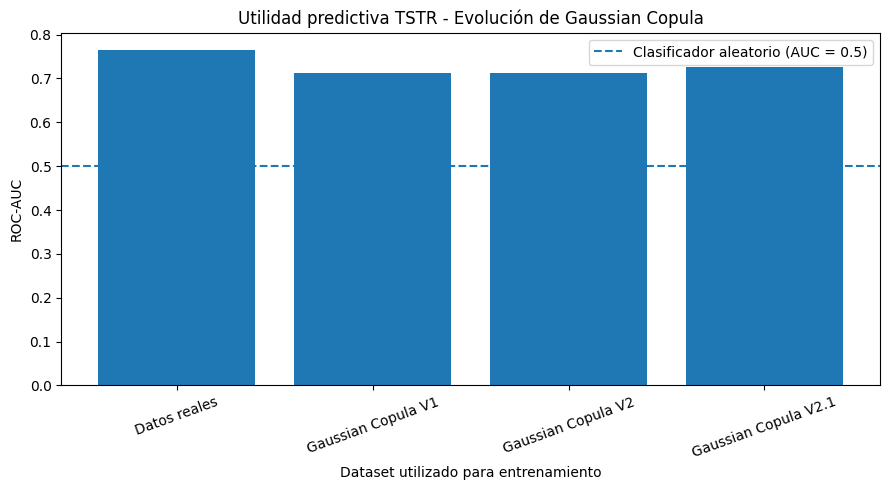

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

plt.bar(
    resultados_finales_gc["Dataset"],
    resultados_finales_gc["ROC_AUC"]
)

plt.axhline(
    y=0.5,
    linestyle="--",
    label="Clasificador aleatorio (AUC = 0.5)"
)

plt.ylabel("ROC-AUC")
plt.xlabel("Dataset utilizado para entrenamiento")

plt.title(
    "Utilidad predictiva TSTR - Evolución de Gaussian Copula"
)

plt.xticks(rotation=20)

plt.legend()

plt.tight_layout()
plt.show()

##### 5.7.6.6 Mejora entre iteraciones

In [ ]:
#También quiero que calculemos explícitamente cuánto mejoró V2.1 respecto a las versiones anteriores.
auc_v1 = resultados_finales_gc.loc[
    resultados_finales_gc["Dataset"] == "Gaussian Copula V1",
    "ROC_AUC"
].iloc[0]

auc_v2 = resultados_finales_gc.loc[
    resultados_finales_gc["Dataset"] == "Gaussian Copula V2",
    "ROC_AUC"
].iloc[0]

auc_v21 = resultados_finales_gc.loc[
    resultados_finales_gc["Dataset"] == "Gaussian Copula V2.1",
    "ROC_AUC"
].iloc[0]


print(
    f"Mejora V1 → V2: "
    f"{auc_v2 - auc_v1:+.4f}"
)

print(
    f"Mejora V2 → V2.1: "
    f"{auc_v21 - auc_v2:+.4f}"
)

print(
    f"Mejora V1 → V2.1: "
    f"{auc_v21 - auc_v1:+.4f}"
)

Mejora V1 → V2: -0.0007
Mejora V2 → V2.1: +0.0147
Mejora V1 → V2.1: +0.0140


##### 5.7.6.7 Conclusión de Gaussian Copula

Conclusión de la optimización de Gaussian Copula

Los experimentos realizados evidencian que la calidad de un dataset sintético no debe evaluarse únicamente a partir de la similitud de sus distribuciones marginales. La primera generación mediante Gaussian Copula conservó determinadas características estadísticas generales, pero presentó una pérdida significativa de las relaciones predictivas relevantes para la estimación de TARGET.

El diagnóstico de importancia predictiva permitió identificar las variables y dependencias más relevantes del dataset real. A partir de estos resultados se modificó el proceso de generación, diferenciando variables base y derivadas, reconstruyendo estas últimas determinísticamente y ajustando el tratamiento de determinadas variables discretas.

La versión V2.1 produjo una mejora sustancial en la representación de CNT_CHILDREN y CNT_FAM_MEMBERS, así como una reducción del 30.90 % en el error medio de las correlaciones correspondientes a las variables predictivas críticas.

Esta mejora estadística también se trasladó a la utilidad predictiva. En un esquema TSTR (Train on Synthetic, Test on Real), el modelo LightGBM entrenado exclusivamente con Gaussian Copula V2.1 alcanzó un ROC-AUC de 0.7267, frente a 0.7656 obtenido mediante entrenamiento con datos reales, representando aproximadamente el 94.9 % del ROC-AUC del baseline real.

No obstante, determinadas dependencias estructurales continuaron presentando pérdidas relevantes, evidenciando las limitaciones de Gaussian Copula para reproducir completamente estructuras multivariantes complejas. En consecuencia, V2.1 se establece como la versión optimizada y definitiva de Gaussian Copula para los experimentos posteriores.

#### 5.7.7 Conclusiones de la optimización de Gaussian Copula

Los resultados obtenidos evidencian que la evaluación de la calidad de los datos sintéticos no debe limitarse exclusivamente a la similitud de sus distribuciones marginales, sino que debe considerar también la conservación de las relaciones multivariantes y, especialmente, de aquellas asociaciones relevantes para la variable objetivo.

La primera versión generada mediante Gaussian Copula (V1) alcanzó un ROC-AUC de 0.7127 bajo un esquema TSTR (Train on Synthetic, Test on Real), frente al 0.7656 obtenido mediante entrenamiento con datos reales. El análisis posterior permitió detectar pérdidas relevantes en determinadas relaciones estructurales y predictivas.

En V2 se modificó el proceso de síntesis separando las variables originales de aquellas derivadas mediante relaciones determinísticas, generándose únicamente las variables base y reconstruyéndose posteriormente las variables derivadas. Esta estrategia mejoró la coherencia estructural del dataset; sin embargo, no produjo una mejora de la utilidad predictiva, obteniéndose un ROC-AUC de 0.7120, prácticamente equivalente al obtenido en V1.

A partir del diagnóstico de importancia predictiva realizado sobre el dataset real se desarrolló una tercera configuración, denominada V2.1. En esta versión se modificó el tratamiento semántico de determinadas variables discretas y se incorporó generación condicionada respecto a TARGET. Como resultado, las distribuciones de variables como CNT_CHILDREN y CNT_FAM_MEMBERS se aproximaron considerablemente a las observadas en los datos reales. Asimismo, el error medio de las correlaciones correspondientes a las variables predictivas críticas se redujo en un 30.90% respecto a V2.

Esta mejora estadística se trasladó también a la utilidad predictiva. Gaussian Copula V2.1 alcanzó un ROC-AUC TSTR de 0.7267, mejorando aproximadamente 0.0147 puntos respecto a V2 y 0.0140 puntos respecto a V1. El gap respecto al modelo entrenado con datos reales se redujo hasta 0.0389, obteniéndose un ROC-AUC equivalente al 94.92% del baseline real.

No obstante, determinadas dependencias estructurales continuaron sin ser reproducidas adecuadamente, como la relación existente entre DEF_30_CNT_SOCIAL_CIRCLE y DEF_60_CNT_SOCIAL_CIRCLE. Estos resultados muestran que la optimización del proceso de síntesis permite incrementar la fidelidad y utilidad de Gaussian Copula, aunque persisten limitaciones para representar completamente determinadas estructuras multivariantes complejas.

En consecuencia, V2.1 se selecciona como la configuración definitiva de Gaussian Copula para las comparaciones posteriores con otros métodos de generación sintética.

**HAsta qeui lo que hemos respondido es: ¿Un modelo que aprende únicamente de los datos sintéticos puede transferir ese conocimiento a datos reales?**

In [ ]:
#Prueba extra TSTS (Validar sutilidad)
from sklearn.model_selection import train_test_split

X_v21 = df_synth_v21.drop(
    columns=["TARGET", "SK_ID_CURR"]
).copy()

y_v21 = df_synth_v21["TARGET"].copy()

X_train_v21, X_test_v21, y_train_v21, y_test_v21 = train_test_split(
    X_v21,
    y_v21,
    test_size=0.20,
    stratify=y_v21,
    random_state=42
)

print("Synthetic Train:", X_train_v21.shape)
print("Synthetic Test :", X_test_v21.shape)

print("\nTARGET Train:")
print(y_train_v21.value_counts(normalize=True))

print("\nTARGET Test:")
print(y_test_v21.value_counts(normalize=True))

Synthetic Train: (246005, 39)
Synthetic Test : (61502, 39)

TARGET Train:
TARGET
0    0.91927
1    0.08073
Name: proportion, dtype: float64

TARGET Test:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


In [ ]:
#Preparamos el encoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

cat_features_v21_sts = (
    X_train_v21
    .select_dtypes(
        include=["object", "category"]
    )
    .columns
    .tolist()
)

encoder_v21_sts = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            cat_features_v21_sts
        )
    ],
    remainder="passthrough"
)

X_train_v21_enc = encoder_v21_sts.fit_transform(
    X_train_v21
)

X_test_v21_enc = encoder_v21_sts.transform(
    X_test_v21
)

print("Train encoded:", X_train_v21_enc.shape)
print("Test encoded :", X_test_v21_enc.shape)

Train encoded: (246005, 150)
Test encoded : (61502, 150)


In [ ]:
#Entrenamos LightGBM
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score

modelo_sts_v21 = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    random_state=42,
    n_jobs=-1,
    verbosity=-1
)

modelo_sts_v21.fit(
    X_train_v21_enc,
    y_train_v21
)

y_prob_sts_v21 = modelo_sts_v21.predict_proba(
    X_test_v21_enc
)[:, 1]

auc_sts_v21 = roc_auc_score(
    y_test_v21,
    y_prob_sts_v21
)

print(
    f"ROC-AUC Synthetic → Synthetic V2.1: "
    f"{auc_sts_v21:.6f}"
)

ROC-AUC Synthetic → Synthetic V2.1: 0.621809


Interpretación conjunta TRTR – TSTR – TSTS

| Escenario | Train | Test |      ROC-AUC | Interpretación                 |
| --------- | ----- | ---- | -----------: | ------------------------------ |
| **TRTR**  | Real  | Real | **0.765600** | Baseline                       |
| **TSTR**  | V2.1  | Real | **0.726674** | Transferencia sintético → real |
| **TSTS**  | V2.1  | V2.1 | **0.621809** | Utilidad interna sintética     |


In [ ]:
#Calculamos dos retenciones por separado
auc_trtr = 0.765600
auc_tstr = 0.726674
auc_tsts = 0.621809

retencion_tstr = (
    auc_tstr / auc_trtr
) * 100

retencion_tsts = (
    auc_tsts / auc_trtr
) * 100

gap_tstr = auc_trtr - auc_tstr
gap_tsts = auc_trtr - auc_tsts

print(
    f"Retención ROC-AUC TSTR: "
    f"{retencion_tstr:.2f}%"
)

print(
    f"Retención ROC-AUC TSTS: "
    f"{retencion_tsts:.2f}%"
)

print(
    f"\nGap TRTR-TSTR: {gap_tstr:.6f}"
)

print(
    f"Gap TRTR-TSTS: {gap_tsts:.6f}"
)

print(
    f"Gap TSTR-TSTS: "
    f"{auc_tstr - auc_tsts:.6f}"
)

Retención ROC-AUC TSTR: 94.92%
Retención ROC-AUC TSTS: 81.22%

Gap TRTR-TSTR: 0.038926
Gap TRTR-TSTS: 0.143791
Gap TSTR-TSTS: 0.104865


In [ ]:
#Tabla definitiva de utilidad
resultados_utilidad_v21 = pd.DataFrame({
    "Escenario": [
        "TRTR",
        "TSTR",
        "TSTS"
    ],

    "Entrenamiento": [
        "Real",
        "Sintético V2.1",
        "Sintético V2.1"
    ],

    "Evaluación": [
        "Real",
        "Real",
        "Sintético V2.1"
    ],

    "ROC_AUC": [
        auc_trtr,
        auc_tstr,
        auc_tsts
    ]
})

resultados_utilidad_v21["Gap_vs_TRTR"] = (
    auc_trtr -
    resultados_utilidad_v21["ROC_AUC"]
)

resultados_utilidad_v21["ROC_AUC_relativo_pct"] = (
    resultados_utilidad_v21["ROC_AUC"]
    / auc_trtr
    * 100
)

display(
    resultados_utilidad_v21.round(4)
)

,Escenario,Entrenamiento,Evaluación,ROC_AUC,Gap_vs_TRTR,ROC_AUC_relativo_pct
0,TRTR,Real,Real,0.7656,0.0000,100.0000
1,TSTR,Sintético V2.1,Real,0.7267,0.0389,94.9156
2,TSTS,Sintético V2.1,Sintético V2.1,0.6218,0.1438,81.2185


Una precaución metodológica importante

Hay algo que debemos mantener claro de aquí en adelante: TSTS tiene que hacerse con un split del sintético que no haya participado en el entrenamiento del modelo, como acabamos de hacer.

Pero tanto train como test sintéticos proceden del mismo sintetizador previamente ajustado sobre todo el dataset real. Por tanto, TSTS mide utilidad interna del dataset sintético generado, pero no debe interpretarse como una validación completamente independiente del proceso generativo.

Eso lo podemos mencionar como limitación metodológica.

In [ ]:
#Guardar df_synth_v21
#df_synth_v21.to_csv("/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM/05_Synthetic_Data_Optimization/df_synth_v21.csv", index=False)

In [ ]:
#Guardar dataset en mi drive
#ruta = "/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM//05_Synthetic_Data_Optimization/df_synth_v21.parquet"

#df_synth_v21.to_parquet(
#    ruta,
#    index=False
#)

In [ ]:
#Guardar dataset en mi drive
#ruta = "/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM//05_Synthetic_Data_Optimization/X_test_real.parquet"
#
#X_test_real.to_parquet(
#    ruta,
#    index=False
#)

In [ ]:
#ruta = "/content/drive/MyDrive/Maestria VIU/Tesis/Notebooks/TFM//05_Synthetic_Data_Optimization/y_test_real.parquet"
#
#y_test_real.to_frame().to_parquet(
#    ruta,
#    index=False
#)